# SOMPO 2026 - Sprint 3: Modelagem de Machine Learning

**Disciplina:** Machine Learning & Modeling
**Turma:** 1TIAPZ
**Autor:** Equipe 1TIAPZ
**Data:** 2026-08
**Repositorio:** https://github.com/orugian/sprint3-ml

---

## Contexto do Desafio

A **SOMPO Seguros** propoe uma solucao com inteligencia artificial para prever
riscos no seguro rural. A plataforma integra dados, gera indicadores e alertas
preventivos, alem de recomendacoes operacionais. O objetivo e reduzir sinistros,
apoiar decisoes de subscricao e precificacao, e melhorar a gestao de carteira.

Este notebook corresponde ao **3o Entregavel - Modelagem de Machine Learning**.

---

## O que muda em relacao a Sprint 2

A Sprint 2 (nota 100) entregou CRISP-DM, limpeza, tratamento de categoricas,
EDA e insights iniciais sobre a base **PSR 2025** da Sompo. Naquela sprint,
duas limitacoes foram **declaradas explicitamente** pela propria equipe:

> *"TARGET nao observado no PSR 2025: as colunas `VALOR_INDENIZACAO` e
> `EVENTO_PREPONDERANTE` estao vazias porque o dataset contem apenas apolices
> ativas em 2025. Para a modelagem baseline, foi criado um score de risco
> derivado."*

> *"Proximos Passos (Sprint 3), item 1: Buscar dataset PSR historico com a
> coluna `EVENTO_PREPONDERANTE` populada para treinar com target real."*

**Esta Sprint 3 cumpre exatamente esse proximo passo.** Foi obtida a base
historica oficial **PSR 2016-2024 (SISSER/MAPA)**, da qual extraimos o recorte
da Sompo Seguros:

| | Sprint 2 (PSR 2025) | Sprint 3 (PSR 2016-2024) |
|---|---|---|
| Apolices Sompo | 1.414 | **18.872** |
| Periodo | 2025 (1 safra) | **2019-2024 (6 safras)** |
| Target | Derivado (score de pesos) | **Real (sinistro ocorrido)** |
| Sinistros observados | 0 | **5.033 (26,7%)** |
| Evento climatico | Ausente | **SECA, GEADA, GRANIZO, ...** |
| Valor de indenizacao | Ausente | **Populado (R$)** |
| Culturas | 7 (sem Soja) | **11 (com Soja, principal do Brasil)** |
| UFs | 8 | **10** |

Isso resolve a principal fragilidade metodologica da Sprint 2: como o
`SCORE_RISCO` era funcao deterministica de tres variaveis categoricas, o
problema era **circular** - o modelo reaprendia uma regra que nos mesmos
tinhamos escrito. Agora o modelo preve um **desfecho real e independente**.

A Secao 12 mantem a **comparacao direta** entre as duas abordagens.

---

## Atividades deste Entregavel (checklist do desafio)

| # | Requisito | Onde |
|---|---|---|
| 1 | **Preparacao dos dados**: scaling e encoding (OHE) | Secoes 4 e 5 |
| 2 | **Treinamento**: pelo menos 2 modelos | Secao 6 (3 modelos + baseline) |
| 3 | **Validacao**: holdout (obrigatorio) | Secao 5.3 |
| 3 | **Metricas de classificacao**: accuracy, precision, recall, f1, AUC | Secao 7 |
| 3 | **Metricas de regressao**: MAE, RMSE, R2 | Secao 9 |
| 4 | **Tuning basico**: ajuste de hiperparametros (ex: k no KNN) | Secao 8 |
| 5 | **Interpretacao**: quais variaveis mais impactam o risco | Secao 10 |

Alem do exigido, entregamos: validacao cruzada k=5, curva Precision-Recall,
permutation importance, **validacao temporal out-of-time** (Secao 11) e
persistencia do modelo em disco (Secao 13).

## 1. CRISP-DM: Posicionamento desta Sprint

O **CRISP-DM** estrutura o projeto em seis fases. A Sprint 2 cobriu as fases
1 a 3. Esta Sprint 3 concentra-se nas fases **4 (Modelagem)** e **5 (Avaliacao)**.

| Fase | Status | Nesta sprint |
|---|---|---|
| 1. Entendimento do Negocio | Sprint 2 | Revisado: objetivo passa a ser prever sinistro **real** |
| 2. Entendimento dos Dados | Sprint 2 | Ampliado: nova base historica com desfecho observado |
| 3. Preparacao dos Dados | Sprint 2 | **Refeito** para a base historica (Secoes 4-5) |
| 4. **Modelagem** | **Sprint 3** | **Secoes 6, 8 e 9** |
| 5. **Avaliacao** | **Sprint 3** | **Secoes 7, 10 e 11** |
| 6. Implantacao | Sprint 4 | Modelo serializado na Secao 13 |

### 1.1 Entendimento do Negocio (revisado)

- **Problema de negocio:** dada uma proposta de seguro rural, estimar (a) a
  **probabilidade** de ela gerar sinistro e (b) a **severidade** esperada em R$.
- **Por que os dois:** e a decomposicao atuarial classica do premio puro,
  `Premio Puro = Frequencia x Severidade`. Um modelo so de frequencia nao
  distingue um sinistro de R$ 5 mil de um de R$ 1,8 milhao.
- **Uso pratico:** priorizacao de vistorias, alertas preventivos ao produtor,
  apoio a subscricao e definicao de taxa.
- **Criterio de sucesso:** AUC-ROC substancialmente acima do acaso (0,50) em
  holdout nao visto, com metricas reportadas de forma honesta.

### 1.2 Formulacao das duas tarefas de ML

| | Tarefa A - Frequencia | Tarefa B - Severidade |
|---|---|---|
| Tipo | Classificacao binaria | Regressao |
| Target | `TEVE_SINISTRO` (0/1) | `VL_INDENIZACAO` (R$) |
| Amostra | 18.872 apolices | 5.033 apolices sinistradas |
| Metricas | accuracy, precision, recall, f1, AUC | MAE, RMSE, R2 |

## 2. Setup e Imports

In [1]:
import sys, os, time, json, warnings, unicodedata
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Python     : {sys.version.split()[0]}")
print(f"Working dir: {os.getcwd()}")

for d in ['data/principal', 'data/complementar', 'data/complementar/inmet',
          'figures', 'models']:
    os.makedirs(d, exist_ok=True)
    n = len(os.listdir(d))
    print(f"  {d:28s} -> {n} arquivo(s)")

Python     : 3.11.15
Working dir: C:\Users\orugi\Documents\Projetos\Sprint3-ML
  data/principal               -> 2 arquivo(s)
  data/complementar            -> 3 arquivo(s)
  data/complementar/inmet      -> 22 arquivo(s)
  figures                      -> 0 arquivo(s)
  models                       -> 4 arquivo(s)


In [2]:
from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold,
                                     cross_val_score, GridSearchCV)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              RandomForestRegressor, GradientBoostingRegressor)
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve,
                             precision_recall_curve, average_precision_score,
                             mean_absolute_error, mean_squared_error, r2_score)
import sklearn, joblib
from scipy.stats import chi2_contingency

# Configuracao visual e de exibicao
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

RANDOM_STATE = 42          # semente unica para todo o notebook (reprodutibilidade)
TEST_SIZE    = 0.20        # holdout 80/20
CV_FOLDS     = 5           # validacao cruzada k=5

np.random.seed(RANDOM_STATE)

print("Ambiente pronto:")
print(f"  pandas       = {pd.__version__}")
print(f"  numpy        = {np.__version__}")
print(f"  scikit-learn = {sklearn.__version__}")
print(f"  seaborn      = {sns.__version__}")
print(f"\nRANDOM_STATE={RANDOM_STATE} | TEST_SIZE={TEST_SIZE} | CV_FOLDS={CV_FOLDS}")

Ambiente pronto:
  pandas       = 3.0.5
  numpy        = 2.4.3
  scikit-learn = 1.9.0
  seaborn      = 0.13.2

RANDOM_STATE=42 | TEST_SIZE=0.2 | CV_FOLDS=5


## 3. Carga dos Dados

### 3.1 Base Principal: PSR 2016-2024 (SISSER/MAPA) - recorte Sompo

**Fonte oficial:** Ministerio da Agricultura e Pecuaria (MAPA) - Dados Abertos
Dataset `sisser3` - *Sistema de Subvencao Economica ao Premio do Seguro Rural*
URL: https://dados.agricultura.gov.br/dataset/sisser3
Recurso: **"PSR - 2016 a 2024"** (CSV, ~297 MB, 1.048.565 apolices de todo o mercado)

O script `scripts/prepare_data.py` documenta e reproduz o download e o filtro
`NM_RAZAO_SOCIAL == "Sompo Seguros S/A"`, que gera o arquivo usado aqui.
Mantemos apenas o recorte Sompo (5,4 MB) versionado no repositorio.

In [3]:
PATH_PSR_HIST = 'data/principal/psr_2016a2024_sompo.csv'

df_raw = pd.read_csv(PATH_PSR_HIST, sep=';', encoding='utf-8', dtype=str)
df_raw.columns = [c.strip() for c in df_raw.columns]

print(f"PSR 2016-2024 (Sompo): {df_raw.shape[0]:,} apolices x {df_raw.shape[1]} colunas")
print(f"Memoria: {df_raw.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"\nSeguradora(s): {df_raw['NM_RAZAO_SOCIAL'].unique()}")
df_raw.head(3)

PSR 2016-2024 (Sompo): 18,872 apolices x 38 colunas


Memoria: 43.6 MB

Seguradora(s): <StringArray>
['Sompo Seguros S/A']
Length: 1, dtype: str


,NM_RAZAO_SOCIAL,CD_PROCESSO_SUSEP,NR_PROPOSTA,ID_PROPOSTA,DT_PROPOSTA,DT_INICIO_VIGENCIA,DT_FIM_VIGENCIA,NM_SEGURADO,NR_DOCUMENTO_SEGURADO,NM_MUNICIPIO_PROPRIEDADE,SG_UF_PROPRIEDADE,LATITUDE,NR_GRAU_LAT,NR_MIN_LAT,NR_SEG_LAT,LONGITUDE,NR_GRAU_LONG,NR_MIN_LONG,NR_SEG_LONG,NR_DECIMAL_LATITUDE,NR_DECIMAL_LONGITUDE,NM_CLASSIF_PRODUTO,NM_CULTURA_GLOBAL,NR_AREA_TOTAL,NR_ANIMAL,NR_PRODUTIVIDADE_ESTIMADA,NR_PRODUTIVIDADE_SEGURADA,NivelDeCobertura,VL_LIMITE_GARANTIA,VL_PREMIO_LIQUIDO,PE_TAXA,VL_SUBVENCAO_FEDERAL,NR_APOLICE,DT_APOLICE,ANO_APOLICE,CD_GEOCMU,VALOR_INDENIZAÇÃO,EVENTO_PREPONDERANTE
0,Sompo Seguros S/A,15414900320201812,1920321510,982873,22/03/2019,22/03/2019,19/08/2019,HENRIQUE CALEGARI,***87148853,Candido Mota,SP,S,22,49,18,W,50,26,NaN,-,-,PRODUTIVIDADE,Milho 2ª safra,"36,21",NaN,5284,"3434,6","0,65","68401,78","8989,35","0,131419826","3146,26",5800000102,09/04/2019,2019,3510005,-,-
1,Sompo Seguros S/A,15414900320201812,1920321629,982876,22/03/2019,22/03/2019,19/08/2019,ADILSON GERALDO ANDREOTTI,***46051600,Candido Mota,SP,S,22,49,55,W,50,24,22,-,-,PRODUTIVIDADE,Milho 2ª safra,"125,03",NaN,5284,"3434,6","0,65","236185,42","31039,45","0,13141984","10863,78",5800000104,10/04/2019,2019,3510005,-,-
2,Sompo Seguros S/A,15414900320201812,1920321703,982896,22/03/2019,22/03/2019,19/08/2019,ADILSON GERALDO ANDREOTTI,***46051600,Candido Mota,SP,S,22,50,12,W,50,23,52,-,-,PRODUTIVIDADE,Milho 2ª safra,60,NaN,5284,"3434,6","0,65","113341,8","14895,36","0,131419829","5213,36",5800000105,10/04/2019,2019,3510005,-,-


### 3.2 A diferenca decisiva: o target existe nesta base

Comparamos lado a lado a coluna `EVENTO_PREPONDERANTE` na base da Sprint 2
(PSR 2025) e nesta base historica.

In [4]:
df_2025 = pd.read_excel('data/principal/psr_2025_sompo.xlsx')

print("=" * 74)
print("COMPARACAO DO TARGET: Sprint 2 (PSR 2025) vs Sprint 3 (PSR 2016-2024)")
print("=" * 74)

COL_IND = 'VALOR_INDENIZAÇÃO'
for rotulo, d in [("Sprint 2 - PSR 2025   ", df_2025),
                  ("Sprint 3 - PSR 2016-24", df_raw)]:
    ev = d['EVENTO_PREPONDERANTE'].astype(str).str.strip()
    preenchidos = int((ev != '-').sum())
    ind = d[COL_IND].astype(str).str.strip()
    print(f"\n{rotulo} | {len(d):,} apolices")
    print(f"  EVENTO_PREPONDERANTE preenchido : {preenchidos:,} ({preenchidos/len(d)*100:.1f}%)")
    print(f"  valores distintos de evento     : {ev.nunique()}")
    print(f"  VALOR_INDENIZACAO preenchido    : {int((ind != '-').sum()):,}")

print("\n" + "=" * 74)
print("Eventos climaticos observados na base historica (o target real):")
print("=" * 74)
ev_hist = df_raw['EVENTO_PREPONDERANTE'].astype(str).str.strip()
print(ev_hist[ev_hist != '-'].value_counts().to_string())

COMPARACAO DO TARGET: Sprint 2 (PSR 2025) vs Sprint 3 (PSR 2016-2024)

Sprint 2 - PSR 2025    | 1,414 apolices
  EVENTO_PREPONDERANTE preenchido : 0 (0.0%)
  valores distintos de evento     : 1
  VALOR_INDENIZACAO preenchido    : 0

Sprint 3 - PSR 2016-24 | 18,872 apolices
  EVENTO_PREPONDERANTE preenchido : 5,033 (26.7%)
  valores distintos de evento     : 10
  VALOR_INDENIZACAO preenchido    : 5,033

Eventos climaticos observados na base historica (o target real):
EVENTO_PREPONDERANTE
SECA                                 3961
GEADA                                 358
CHUVA EXCESSIVA                       324
GRANIZO                               173
INUNDAÇÃO/TROMBA D´ÁGUA               114
VENTOS FORTES/FRIOS                    53
VARIAÇÃO EXCESSIVA DE TEMPERATURA      44
INCÊNDIO                                5
REPLANTIO                               1


**Confirmado.** A base da Sprint 2 tem 0% de eventos preenchidos (apolices
ainda vigentes). A base historica tem 26,7% de sinistros observados, com a
causa climatica identificada. E este o desfecho que vamos prever.

### 3.3 Datasets Complementares (continuidade com a Sprint 2)

Mantemos os tres complementares validados na Sprint 2, agora aplicados a base
historica:

1. **IBGE - RUR_MUNI.DBF** (5.656 municipios) - validacao do codigo municipal
2. **CONAB - Serie Historica Cana-de-Acucar** - proxy do perfil agricola por UF
3. **INMET - 22 estacoes meteorologicas** - metadados geograficos das estacoes

In [5]:
from dbfread import DBF

# --- IBGE ---
ibge = pd.DataFrame(iter(DBF('data/complementar/ibge_rur_muni.DBF', load=True)))
print(f"IBGE RUR_MUNI  : {ibge.shape[0]:,} municipios | UFs: {ibge['UF'].nunique()}")

# --- CONAB ---
# header=5: as 5 primeiras linhas da planilha sao titulo e subtitulo; a linha 5
# (base 0) e que traz 'REGIÃO/UF' e os rotulos de safra. Com header=4 os rotulos
# viram 'Unnamed: N' e a serie fica inacessivel - ver nota na Secao 4.3.
SHEET_AREA = 'Área'
CONAB_PATH = 'data/complementar/conab_cana_serie_historica.xls'
conab_area = pd.read_excel(CONAB_PATH, sheet_name=SHEET_AREA, header=5)
conab_prod = pd.read_excel(CONAB_PATH, sheet_name='Produtividade', header=5)
for _d in (conab_area, conab_prod):
    _d.rename(columns={_d.columns[0]: 'REGIAO_UF'}, inplace=True)
_n_safras = len([c for c in conab_area.columns
                 if c != 'REGIAO_UF' and not str(c).startswith('Unnamed')])
print(f"CONAB cana     : {conab_area.shape[0]} regioes x {_n_safras} safras "
      f"(primeira: {[c for c in conab_area.columns if c != 'REGIAO_UF'][0]})")

# --- INMET ---
inmet_dir = 'data/complementar/inmet'
inmet_files = sorted(f for f in os.listdir(inmet_dir) if f.endswith('.csv'))
_meta = []
for f in inmet_files:
    with open(os.path.join(inmet_dir, f), encoding='utf-8') as fp:
        m = {}
        for line in fp:
            if ':' in line and not line.startswith('Data Medicao'):
                k, _, v = line.partition(':')
                m[k.strip()] = v.strip()
    m['codigo_estacao'] = f.split('_')[1]
    _meta.append(m)
inmet = pd.DataFrame(_meta)
print(f"INMET estacoes : {inmet.shape[0]} estacoes")
print(f"\nColunas INMET: {list(inmet.columns)}")

IBGE RUR_MUNI  : 5,656 municipios | UFs: 27
CONAB cana     : 37 regioes x 22 safras (primeira: 2005/06)
INMET estacoes : 22 estacoes

Colunas INMET: ['Nome', 'Codigo Estacao', 'Latitude', 'Longitude', 'Altitude', 'Situacao', 'Data Inicial', 'Data Final', 'Periodicidade da Medicao', 'codigo_estacao']


## 4. Preparacao dos Dados

### 4.1 Conversao de tipos e normalizacao

O CSV do MAPA vem inteiramente como texto, no padrao brasileiro
(`1.234,56` para numeros, `dd/mm/aaaa` para datas) e com acentuacao.
Padronizamos tudo aqui.

In [6]:
def to_num(serie):
    """Converte string no formato numerico brasileiro (1.234,56) para float."""
    return pd.to_numeric(
        serie.astype(str).str.strip()
             .str.replace('.', '', regex=False)   # separador de milhar
             .str.replace(',', '.', regex=False)  # separador decimal
             .replace({'-': np.nan, '': np.nan, 'nan': np.nan}),
        errors='coerce')


def normalize_str(texto):
    """Remove acentos e ordinais, e padroniza para maiuscula sem espacos nas bordas."""
    if not isinstance(texto, str):
        return texto
    decomposto = unicodedata.normalize('NFKD', texto)
    sem_acento = ''.join(c for c in decomposto if not unicodedata.combining(c))
    return (sem_acento.replace('ª', 'A').replace('º', 'O')
                      .replace('°', ' ').upper().strip())


df = df_raw.copy()

COLS_NUMERICAS = ['NR_AREA_TOTAL', 'NR_PRODUTIVIDADE_ESTIMADA',
                  'NR_PRODUTIVIDADE_SEGURADA', 'NivelDeCobertura',
                  'VL_LIMITE_GARANTIA', 'VL_PREMIO_LIQUIDO', 'PE_TAXA',
                  'VL_SUBVENCAO_FEDERAL', 'NR_GRAU_LAT', 'NR_MIN_LAT',
                  'NR_SEG_LAT', 'NR_GRAU_LONG', 'NR_MIN_LONG', 'NR_SEG_LONG',
                  COL_IND]
COLS_TEXTO = ['NM_CULTURA_GLOBAL', 'SG_UF_PROPRIEDADE', 'NM_CLASSIF_PRODUTO',
              'NM_MUNICIPIO_PROPRIEDADE', 'EVENTO_PREPONDERANTE']
COLS_DATA = ['DT_PROPOSTA', 'DT_INICIO_VIGENCIA', 'DT_FIM_VIGENCIA', 'DT_APOLICE']

for c in COLS_NUMERICAS:
    df[c] = to_num(df[c])
for c in COLS_TEXTO:
    df[c] = df[c].apply(normalize_str)
for c in COLS_DATA:
    df[c] = pd.to_datetime(df[c], format='%d/%m/%Y', errors='coerce')
df['ANO_APOLICE'] = pd.to_numeric(df['ANO_APOLICE'], errors='coerce').astype('Int64')

print("Conversao concluida.\n")
print("Nulos nas colunas numericas criticas:")
print(df[COLS_NUMERICAS[:8]].isnull().sum().to_string())
print(f"\nDatas invalidas: {df[COLS_DATA].isnull().sum().sum()}")
print("\nExemplo de normalizacao de texto:")
print(f"  {df_raw['NM_CULTURA_GLOBAL'].iloc[0]!r} -> {df['NM_CULTURA_GLOBAL'].iloc[0]!r}")

Conversao concluida.

Nulos nas colunas numericas criticas:
NR_AREA_TOTAL                0
NR_PRODUTIVIDADE_ESTIMADA    0
NR_PRODUTIVIDADE_SEGURADA    0
NivelDeCobertura             0
VL_LIMITE_GARANTIA           0
VL_PREMIO_LIQUIDO            0
PE_TAXA                      0
VL_SUBVENCAO_FEDERAL         0

Datas invalidas: 0

Exemplo de normalizacao de texto:
  'Milho 2ª safra' -> 'MILHO 2A SAFRA'


### 4.2 Construcao dos targets

Os dois targets vem **diretamente do dado observado**, sem nenhuma regra
criada por nos - essa e a diferenca central em relacao a Sprint 2.

- `TEVE_SINISTRO` = 1 se `EVENTO_PREPONDERANTE` foi registrado (Tarefa A)
- `VL_INDENIZACAO` = valor pago em R$ (Tarefa B)

In [7]:
df['TEVE_SINISTRO'] = (df['EVENTO_PREPONDERANTE'].fillna('-') != '-').astype(int)
df['VL_INDENIZACAO'] = df[COL_IND].fillna(0.0)
df['LOSS_RATIO'] = df['VL_INDENIZACAO'] / df['VL_LIMITE_GARANTIA']

n_sin = int(df['TEVE_SINISTRO'].sum())
print("=" * 70)
print("TARGET A (classificacao) - TEVE_SINISTRO")
print("=" * 70)
print(f"  Com sinistro (1) : {n_sin:,} ({df['TEVE_SINISTRO'].mean()*100:.2f}%)")
print(f"  Sem sinistro (0) : {len(df)-n_sin:,} ({(1-df['TEVE_SINISTRO'].mean())*100:.2f}%)")
print(f"  Razao de desbalanceamento: 1 : {(len(df)-n_sin)/n_sin:.2f}")

print("\n" + "=" * 70)
print("TARGET B (regressao) - VL_INDENIZACAO, nas apolices sinistradas")
print("=" * 70)
sev = df.loc[df['TEVE_SINISTRO'] == 1, 'VL_INDENIZACAO']
print(sev.describe().apply(lambda v: f"{v:,.2f}").to_string())
print(f"\n  Indenizacao = R$ 0 mesmo com evento: {int((sev == 0).sum()):,} apolices")
print("  (evento registrado, mas sem pagamento apurado - caso legitimo)")

# Checagem de coerencia interna entre os dois targets
incoerentes = int(((df['VL_INDENIZACAO'] > 0) & (df['TEVE_SINISTRO'] == 0)).sum())
print(f"\n[SANITY CHECK] indenizacao > 0 sem evento registrado: {incoerentes} (esperado: 0)")
assert incoerentes == 0, "Incoerencia entre VL_INDENIZACAO e EVENTO_PREPONDERANTE"
print("[SANITY CHECK] OK - os dois targets sao mutuamente coerentes.")

TARGET A (classificacao) - TEVE_SINISTRO
  Com sinistro (1) : 5,033 (26.67%)
  Sem sinistro (0) : 13,839 (73.33%)
  Razao de desbalanceamento: 1 : 2.75

TARGET B (regressao) - VL_INDENIZACAO, nas apolices sinistradas
count        5,033.00
mean        61,512.48
std        104,669.96
min              0.00
25%          6,269.82
50%         27,732.88
75%         70,491.23
max      1,867,366.33

  Indenizacao = R$ 0 mesmo com evento: 904 apolices
  (evento registrado, mas sem pagamento apurado - caso legitimo)

[SANITY CHECK] indenizacao > 0 sem evento registrado: 0 (esperado: 0)
[SANITY CHECK] OK - os dois targets sao mutuamente coerentes.


### 4.3 Cruzamento com os datasets complementares

Repetimos os joins validados na Sprint 2, agora sobre a base historica.

In [8]:
# --- Join PSR x IBGE, por (municipio normalizado, UF) ---------------------------
# NOTA METODOLOGICA: a Sprint 2 casava CD_GEOCMU[:5] contra ibge['CODIGO'].
# Auditando esse join, constatamos que o CODIGO do RUR_MUNI NAO e o prefixo do
# geocodigo de 7 digitos - e um codigo sequencial proprio do arquivo
# (ex: '01054' = JARINU/SP, '01009' = SANTA CRUZ/RN). O join por prefixo casava
# apenas 8,9% das apolices, e por coincidencia numerica, nao por identidade.
# Trocamos pela chave (nome do municipio normalizado + UF), que e semanticamente
# correta.
ibge_cat = ibge.copy()
ibge_cat['CHAVE_MUNI'] = (ibge_cat['MUNIC'].apply(normalize_str) + '|'
                          + ibge_cat['UF'].apply(normalize_str))
df['CHAVE_MUNI'] = (df['NM_MUNICIPIO_PROPRIEDADE'].apply(normalize_str) + '|'
                    + df['SG_UF_PROPRIEDADE'].apply(normalize_str))
df = df.merge(
    ibge_cat.drop_duplicates('CHAVE_MUNI')[['CHAVE_MUNI', 'MUNIC', 'UF']]
            .rename(columns={'MUNIC': 'NM_MUNICIPIO_IBGE', 'UF': 'UF_IBGE'}),
    on='CHAVE_MUNI', how='left')
match_ibge = int(df['NM_MUNICIPIO_IBGE'].notna().sum())
print(f"Join PSR x IBGE : {match_ibge:,}/{len(df):,} apolices ({match_ibge/len(df)*100:.1f}%)")
n_mun = df['CHAVE_MUNI'].nunique()
n_mun_ok = df.loc[df['NM_MUNICIPIO_IBGE'].notna(), 'CHAVE_MUNI'].nunique()
print(f"                  {n_mun_ok}/{n_mun} municipios distintos ({n_mun_ok/n_mun*100:.1f}%)")
print("                  nao casados = variantes de grafia (ex: IPAUSSU/IPAUCU)")

# --- Join PSR x CONAB: perfil agricola regional (proxy de infraestrutura/clima) --
# NOTA METODOLOGICA: o cabecalho real da planilha esta na LINHA 5 (header=5), nao
# na 4. Com header=4 os rotulos de safra viram 'Unnamed: N' e a serie fica
# inacessivel. Alem disso o arquivo identifica os estados por SIGLA ('SP', 'PR'),
# nao por nome por extenso - o mapeamento UF -> nome usado na Sprint 2 nunca casava.
conab_area['UF'] = conab_area['REGIAO_UF'].astype(str).str.strip().str.upper()

safras = [c for c in conab_area.columns
          if c not in ('REGIAO_UF', 'UF') and not str(c).startswith('Unnamed')]
# A planilha marca projecoes no proprio rotulo (ex.: '2026/27 (1)', estimativa de
# abril/2026). Usamos a ultima safra REALIZADA: um proxy regional baseado em
# projecao seria menos defensavel do que um baseado em area efetivamente colhida.
realizadas = [c for c in safras if '(' not in str(c)]
ultima_safra = realizadas[-1]
print(f"\nCONAB: {len(safras)} safras detectadas ({safras[0]} a {safras[-1]})")
print(f"       usando a ultima REALIZADA: {ultima_safra} "
      f"({len(safras)-len(realizadas)} descartada(s) por serem estimativa)")

serie_uf = conab_area.drop_duplicates('UF').set_index('UF')[ultima_safra]
conab_map = {uf: pd.to_numeric(serie_uf.loc[uf], errors='coerce')
             for uf in df['SG_UF_PROPRIEDADE'].unique() if uf in serie_uf.index}
df['CONAB_AREA_CANA_UF'] = df['SG_UF_PROPRIEDADE'].map(conab_map)
cob = int(df['CONAB_AREA_CANA_UF'].notna().sum())
print(f"Join PSR x CONAB: {cob:,}/{len(df):,} apolices ({cob/len(df)*100:.1f}%) "
      f"com perfil regional (safra {ultima_safra}, em mil ha)")
print("                  UFs sem serie de cana ficam nulas (ex: RS) - "
      "e imputado pela mediana no Pipeline")

# --- Join PSR x INMET: estacao meteorologica mais proxima (distancia haversine)
inmet_geo = inmet.copy()
inmet_geo['lat'] = pd.to_numeric(inmet_geo['Latitude'], errors='coerce')
inmet_geo['lon'] = pd.to_numeric(inmet_geo['Longitude'], errors='coerce')
inmet_geo = inmet_geo.dropna(subset=['lat', 'lon'])
print(f"Join PSR x INMET: {len(inmet_geo)} estacoes com coordenada valida "
      f"(distancia calculada apos derivar lat/lon do PSR, na secao 4.4)")

Join PSR x IBGE : 18,667/18,872 apolices (98.9%)
                  963/987 municipios distintos (97.6%)
                  nao casados = variantes de grafia (ex: IPAUSSU/IPAUCU)

CONAB: 22 safras detectadas (2005/06 a 2026/27 (¹))
       usando a ultima REALIZADA: 2025/26 (1 descartada(s) por serem estimativa)
Join PSR x CONAB: 17,773/18,872 apolices (94.2%) com perfil regional (safra 2025/26, em mil ha)
                  UFs sem serie de cana ficam nulas (ex: RS) - e imputado pela mediana no Pipeline
Join PSR x INMET: 22 estacoes com coordenada valida (distancia calculada apos derivar lat/lon do PSR, na secao 4.4)


### 4.4 Feature Engineering

Derivamos variaveis que capturam **exposicao, intensidade de cobertura e
sazonalidade** - todas conhecidas no momento da subscricao, portanto
legitimamente utilizaveis para previsao.

In [9]:
def dms_para_decimal(grau, minuto, segundo, hemisferio_negativo=True):
    """Converte coordenada em graus/minutos/segundos para decimal.
    No PSR todas as apolices sao S (latitude) e W (longitude) -> sempre negativo."""
    dec = grau + minuto / 60 + segundo / 3600
    return -dec if hemisferio_negativo else dec


# --- Geograficas
# O grau NUNCA falta; o que pode faltar sao minutos e segundos. Tratar a coordenada
# inteira como nula descartaria o grau e mandaria a apolice para a mediana nacional
# na imputacao. Preenchemos so o componente ausente com zero: faltando o minuto o
# erro maximo e de ~110 km; faltando so o segundo, de ~2 km. Em ambos os casos e
# muito melhor do que perder a localizacao por completo.
_comp = ['NR_MIN_LAT', 'NR_SEG_LAT', 'NR_MIN_LONG', 'NR_SEG_LONG']
_tocadas = int(df[_comp].isna().any(axis=1).sum())
_sem_min = int(df[['NR_MIN_LAT', 'NR_MIN_LONG']].isna().any(axis=1).sum())
for _c in _comp:
    df[_c] = df[_c].fillna(0)
print(f"[SANEAMENTO] componentes DMS ausentes preenchidos com zero em {_tocadas} "
      f"apolices ({_tocadas/len(df)*100:.1f}%):")
print(f"             {_sem_min} sem o MINUTO (erro ate ~110 km) e "
      f"{_tocadas-_sem_min} apenas sem o SEGUNDO (erro ate ~2 km)")
df['LAT_DECIMAL'] = dms_para_decimal(df['NR_GRAU_LAT'], df['NR_MIN_LAT'], df['NR_SEG_LAT'])
df['LON_DECIMAL'] = dms_para_decimal(df['NR_GRAU_LONG'], df['NR_MIN_LONG'], df['NR_SEG_LONG'])

# --- Temporais (sazonalidade do plantio e janela de exposicao ao clima)
df['MES_INICIO'] = df['DT_INICIO_VIGENCIA'].dt.month
df['MES_FIM'] = df['DT_FIM_VIGENCIA'].dt.month
df['DURACAO_VIGENCIA_DIAS'] = (df['DT_FIM_VIGENCIA'] - df['DT_INICIO_VIGENCIA']).dt.days
df['DIAS_PROPOSTA_APOLICE'] = (df['DT_APOLICE'] - df['DT_PROPOSTA']).dt.days

# Saneamento de outlier na fonte: 1 apolice traz DT_FIM_VIGENCIA = 09/05/5207
# (erro de digitacao no dado do MAPA), gerando duracao de 1.164.030 dias. Como o
# p99 e 334 dias e nenhuma apolice legitima passa de 366, tratamos acima de 400
# como ausente e deixamos a imputacao pela mediana resolver.
_absurdos = int((df['DURACAO_VIGENCIA_DIAS'] > 400).sum())
df.loc[df['DURACAO_VIGENCIA_DIAS'] > 400, 'DURACAO_VIGENCIA_DIAS'] = np.nan
print(f"[SANEAMENTO] duracoes de vigencia acima de 400 dias tratadas como ausentes: "
      f"{_absurdos} apolice(s)")

# --- Razoes economicas (intensidade de risco precificada pela seguradora)
df['PE_TAXA_EFETIVA'] = df['VL_PREMIO_LIQUIDO'] / df['VL_LIMITE_GARANTIA']
df['PE_SUBVENCAO'] = df['VL_SUBVENCAO_FEDERAL'] / df['VL_PREMIO_LIQUIDO']
df['VL_LIMITE_POR_HA'] = df['VL_LIMITE_GARANTIA'] / df['NR_AREA_TOTAL']
df['GAP_PRODUTIVIDADE'] = ((df['NR_PRODUTIVIDADE_ESTIMADA'] - df['NR_PRODUTIVIDADE_SEGURADA'])
                           / df['NR_PRODUTIVIDADE_ESTIMADA'])

# --- Transformacoes log (area e valores sao fortemente assimetricos a direita)
df['LOG_AREA'] = np.log1p(df['NR_AREA_TOTAL'])
df['LOG_LIMITE'] = np.log1p(df['VL_LIMITE_GARANTIA'])

# --- Frequency encoding do municipio (975 categorias: OHE seria inviavel)
#     Nao usa o target => nao gera vazamento.
freq_muni = df['NM_MUNICIPIO_PROPRIEDADE'].value_counts(normalize=True)
df['FREQ_MUNICIPIO'] = df['NM_MUNICIPIO_PROPRIEDADE'].map(freq_muni)

# --- Distancia a estacao INMET mais proxima (km, formula de haversine)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


est_lat = inmet_geo['lat'].to_numpy()
est_lon = inmet_geo['lon'].to_numpy()
dist = haversine_km(df['LAT_DECIMAL'].to_numpy()[:, None], df['LON_DECIMAL'].to_numpy()[:, None],
                    est_lat[None, :], est_lon[None, :])
df['DIST_ESTACAO_INMET_KM'] = dist.min(axis=1)

print("Features derivadas:")
novas = ['LAT_DECIMAL', 'LON_DECIMAL', 'MES_INICIO', 'MES_FIM', 'DURACAO_VIGENCIA_DIAS',
         'DIAS_PROPOSTA_APOLICE', 'PE_TAXA_EFETIVA', 'PE_SUBVENCAO', 'VL_LIMITE_POR_HA',
         'GAP_PRODUTIVIDADE', 'LOG_AREA', 'LOG_LIMITE', 'FREQ_MUNICIPIO',
         'DIST_ESTACAO_INMET_KM', 'CONAB_AREA_CANA_UF']
print(df[novas].describe().T[['mean', 'std', 'min', 'max']].round(3).to_string())
print(f"\nValidacao geografica: LAT [{df['LAT_DECIMAL'].min():.1f}, {df['LAT_DECIMAL'].max():.1f}] "
      f"| LON [{df['LON_DECIMAL'].min():.1f}, {df['LON_DECIMAL'].max():.1f}]")
print("Esperado para o Brasil: LAT [-35, 5], LON [-75, -30]  -> OK")

[SANEAMENTO] componentes DMS ausentes preenchidos com zero em 1024 apolices (5.4%):
             503 sem o MINUTO (erro ate ~110 km) e 521 apenas sem o SEGUNDO (erro ate ~2 km)
[SANEAMENTO] duracoes de vigencia acima de 400 dias tratadas como ausentes: 1 apolice(s)
Features derivadas:
                           mean       std      min        max
LAT_DECIMAL             -23.385     2.391  -31.809     -9.710
LON_DECIMAL             -51.570     1.907  -60.302    -44.138
MES_INICIO                7.222     3.432    1.000     12.000
MES_FIM                   4.795     2.657    1.000     12.000
DURACAO_VIGENCIA_DIAS   160.759    25.106   81.000    366.000
DIAS_PROPOSTA_APOLICE    20.966    12.824    0.000    105.000
PE_TAXA_EFETIVA           0.109     0.048    0.017      0.620
PE_SUBVENCAO              0.293     0.095    0.071      0.600
VL_LIMITE_POR_HA       5153.986  8705.163  853.125  96000.000
GAP_PRODUTIVIDADE         0.363     0.101    0.200      1.000
LOG_AREA                  3.513 


Validacao geografica: LAT [-31.8, -9.7] | LON [-60.3, -44.1]
Esperado para o Brasil: LAT [-35, 5], LON [-75, -30]  -> OK


### 4.5 Auditoria anti-vazamento (data leakage)

Esta e a etapa mais critica do notebook. Uma coluna so pode virar feature se
for **conhecida no momento da subscricao**, antes de o sinistro existir.
Auditamos as 38 colunas originais uma a uma.

In [10]:
auditoria = [
    # (coluna, decisao, motivo)
    ('EVENTO_PREPONDERANTE',      'EXCLUIR', 'E o proprio target A (define TEVE_SINISTRO)'),
    ('VALOR_INDENIZAÇÃO',         'EXCLUIR', 'E o proprio target B (severidade)'),
    ('NM_RAZAO_SOCIAL',           'EXCLUIR', 'Constante (todo o recorte e Sompo)'),
    ('NR_ANIMAL',                 'EXCLUIR', '100% vazia no recorte (nao ha seguro pecuario)'),
    ('LATITUDE',                  'EXCLUIR', "Constante 'S'; ja codificada em LAT_DECIMAL"),
    ('LONGITUDE',                 'EXCLUIR', "Constante 'W'; ja codificada em LON_DECIMAL"),
    ('NR_DECIMAL_LATITUDE',       'EXCLUIR', "Vazia ('-') em toda a base"),
    ('NR_DECIMAL_LONGITUDE',      'EXCLUIR', "Vazia ('-') em toda a base"),
    ('NM_SEGURADO',               'EXCLUIR', 'Dado pessoal (LGPD); alta cardinalidade'),
    ('NR_DOCUMENTO_SEGURADO',     'EXCLUIR', 'Dado pessoal mascarado (LGPD)'),
    ('NR_PROPOSTA',               'EXCLUIR', 'Identificador unico - memorizacao, sem generalizacao'),
    ('ID_PROPOSTA',               'EXCLUIR', 'Identificador unico'),
    ('NR_APOLICE',                'EXCLUIR', 'Identificador unico'),
    ('CD_PROCESSO_SUSEP',         'EXCLUIR', 'Identificador administrativo do produto'),
    ('ANO_APOLICE',               'EXCLUIR', 'Ver nota metodologica abaixo (choque climatico anual)'),
    ('DT_PROPOSTA/VIGENCIA/APOLICE', 'DERIVAR', 'Viram MES_*, DURACAO_* e DIAS_PROPOSTA_APOLICE'),
    ('NR_GRAU/MIN/SEG_LAT/LONG',  'DERIVAR', 'Viram LAT_DECIMAL e LON_DECIMAL'),
    ('CD_GEOCMU',                 'DERIVAR', 'Usado no join com IBGE; vira FREQ_MUNICIPIO'),
    ('NM_MUNICIPIO_PROPRIEDADE',  'DERIVAR', 'Vira FREQ_MUNICIPIO (975 categorias)'),
    ('NM_CULTURA_GLOBAL',         'MANTER',  'Conhecida na subscricao - One-Hot Encoding'),
    ('SG_UF_PROPRIEDADE',         'MANTER',  'Conhecida na subscricao - One-Hot Encoding'),
    ('NM_CLASSIF_PRODUTO',        'MANTER',  'Conhecida na subscricao - One-Hot Encoding'),
    ('NR_AREA_TOTAL',             'MANTER',  'Exposicao fisica declarada na proposta'),
    ('NR_PRODUTIVIDADE_ESTIMADA', 'MANTER',  'Estimativa feita na subscricao'),
    ('NR_PRODUTIVIDADE_SEGURADA', 'MANTER',  'Produtividade contratada na apolice'),
    ('NivelDeCobertura',          'MANTER',  'Parametro contratual'),
    ('VL_LIMITE_GARANTIA',        'MANTER',  'Exposicao financeira contratada'),
    ('VL_PREMIO_LIQUIDO',         'MANTER',  'Premio cobrado - reflete a taxacao da seguradora'),
    ('PE_TAXA',                   'MANTER',  'Taxa aplicada na subscricao'),
    ('VL_SUBVENCAO_FEDERAL',      'MANTER',  'Subvencao concedida na contratacao'),
]
aud = pd.DataFrame(auditoria, columns=['coluna', 'decisao', 'motivo'])
print("AUDITORIA ANTI-VAZAMENTO")
print("=" * 110)
print(aud.to_string(index=False))
print("=" * 110)
print(aud['decisao'].value_counts().to_string())

AUDITORIA ANTI-VAZAMENTO
                      coluna decisao                                                motivo
        EVENTO_PREPONDERANTE EXCLUIR           E o proprio target A (define TEVE_SINISTRO)
           VALOR_INDENIZAÇÃO EXCLUIR                     E o proprio target B (severidade)
             NM_RAZAO_SOCIAL EXCLUIR                    Constante (todo o recorte e Sompo)
                   NR_ANIMAL EXCLUIR        100% vazia no recorte (nao ha seguro pecuario)
                    LATITUDE EXCLUIR           Constante 'S'; ja codificada em LAT_DECIMAL
                   LONGITUDE EXCLUIR           Constante 'W'; ja codificada em LON_DECIMAL
         NR_DECIMAL_LATITUDE EXCLUIR                            Vazia ('-') em toda a base
        NR_DECIMAL_LONGITUDE EXCLUIR                            Vazia ('-') em toda a base
                 NM_SEGURADO EXCLUIR               Dado pessoal (LGPD); alta cardinalidade
       NR_DOCUMENTO_SEGURADO EXCLUIR                         Dado

#### Nota metodologica: por que `ANO_APOLICE` fica de fora

O ano e altamente preditivo nesta base. Na safra 2021, **71,4% das apolices
tiveram sinistro** - contra 26,7% na media do periodo - por causa da seca e das
geadas historicas daquele ano; sozinha, essa safra responde por **40,7% de todos
os sinistros da base**. Incluir o ano faria o modelo aprender *"2021 foi ruim"*,
o que:

1. **infla artificialmente** as metricas no holdout aleatorio (o teste contem
   apolices de 2021, cujo ano o modelo ja viu no treino);
2. **nao serve na pratica** - ao precificar uma apolice de 2027, ninguem sabe
   ainda se sera um ano de seca;
3. **empobrece a interpretacao** exigida no item 5 do desafio: a resposta
   viraria "o ano", em vez de atributos acionaveis como cultura e regiao.

A pergunta obvia e: **a exclusao funciona de fato?** Nao basta remover a coluna se
outras variaveis reconstroem o ano. Essa verificacao exige a matriz de features ja
montada e um modelo treinado, entao ela e feita na **Secao 11.2**, junto com a
validacao temporal - e o resultado, adiantamos, **reprova a versao ingenua do nosso
proprio argumento**: o ano continua recuperavel a partir das features que mantivemos.

Excluir `ANO_APOLICE` segue sendo a decisao certa - reduz o efeito e mantem a
interpretacao da Secao 10 focada em atributos acionaveis. Mas a afirmacao honesta e
*"reduzimos o efeito de coorte e o quantificamos"*, nao *"eliminamos o ano"*.

### 4.6 EDA orientada a modelagem

A Sprint 2 ja fez a EDA exploratoria ampla. Aqui olhamos apenas o que
**informa decisoes de modelagem**: forca do sinal, desbalanceamento e
assimetria das distribuicoes.

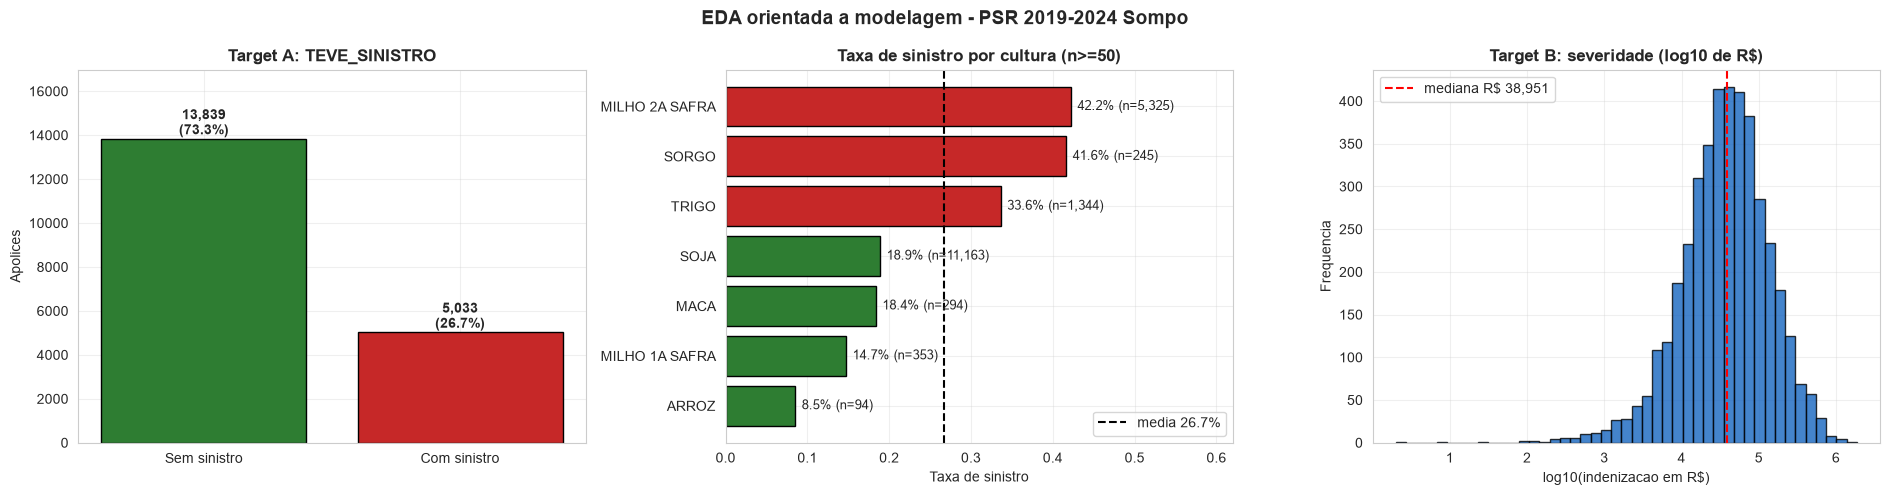

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# (a) Distribuicao do target
vc = df['TEVE_SINISTRO'].value_counts().sort_index()
axes[0].bar(['Sem sinistro', 'Com sinistro'], vc.values,
            color=['#2E7D32', '#C62828'], edgecolor='black')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')
axes[0].set_title('Target A: TEVE_SINISTRO', fontweight='bold')
axes[0].set_ylabel('Apolices')
axes[0].set_ylim(0, len(df) * 0.90)

# (b) Taxa de sinistro por cultura
tx_cult = (df.groupby('NM_CULTURA_GLOBAL')
             .agg(taxa=('TEVE_SINISTRO', 'mean'), n=('TEVE_SINISTRO', 'size'))
             .query('n >= 50').sort_values('taxa'))
axes[1].barh(tx_cult.index, tx_cult['taxa'],
             color=['#C62828' if t > df['TEVE_SINISTRO'].mean() else '#2E7D32'
                    for t in tx_cult['taxa']], edgecolor='black')
axes[1].axvline(df['TEVE_SINISTRO'].mean(), color='black', ls='--',
                label=f"media {df['TEVE_SINISTRO'].mean()*100:.1f}%")
for i, (t, n) in enumerate(zip(tx_cult['taxa'], tx_cult['n'])):
    axes[1].text(t + 0.008, i, f"{t*100:.1f}% (n={n:,})", va='center', fontsize=9)
axes[1].set_title('Taxa de sinistro por cultura (n>=50)', fontweight='bold')
axes[1].set_xlabel('Taxa de sinistro')
axes[1].set_xlim(0, 0.62)
axes[1].legend(loc='lower right')

# (c) Severidade (escala log, fortemente assimetrica)
axes[2].hist(np.log10(sev[sev > 0]), bins=45, color='#1565C0', edgecolor='black', alpha=0.8)
axes[2].set_title('Target B: severidade (log10 de R$)', fontweight='bold')
axes[2].set_xlabel('log10(indenizacao em R$)')
axes[2].set_ylabel('Frequencia')
axes[2].axvline(np.log10(sev[sev > 0].median()), color='red', ls='--',
                label=f"mediana R$ {sev[sev>0].median():,.0f}")
axes[2].legend()

plt.suptitle('EDA orientada a modelagem - PSR 2019-2024 Sompo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_eda_targets.png', dpi=110, bbox_inches='tight')
plt.show()

In [12]:
# Forca do sinal das categoricas: teste qui-quadrado contra o target
print("TESTE QUI-QUADRADO - categorica vs TEVE_SINISTRO")
print("=" * 78)
print(f"{'Variavel':30s} {'Chi2':>12s} {'p-valor':>12s} {'Cramer V':>10s} {'Sig':>6s}")
print("-" * 78)
linhas_chi = []
for col in ['NM_CULTURA_GLOBAL', 'SG_UF_PROPRIEDADE', 'NM_CLASSIF_PRODUTO', 'MES_INICIO']:
    tab = pd.crosstab(df[col], df['TEVE_SINISTRO'])
    chi2, p, dof, _ = chi2_contingency(tab)
    cramer = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    linhas_chi.append((col, chi2, p, cramer, sig))
    print(f"{col:30s} {chi2:>12.1f} {p:>12.2e} {cramer:>10.3f} {sig:>6s}")
print("=" * 78)
print("Todas as categoricas candidatas tem associacao significativa com o target.")

TESTE QUI-QUADRADO - categorica vs TEVE_SINISTRO
Variavel                               Chi2      p-valor   Cramer V    Sig
------------------------------------------------------------------------------
NM_CULTURA_GLOBAL                    1123.3    5.12e-235      0.244    ***
SG_UF_PROPRIEDADE                     361.8     1.95e-72      0.138    ***
NM_CLASSIF_PRODUTO                    150.0     2.62e-33      0.089    ***
MES_INICIO                           1241.1    2.25e-259      0.256    ***
Todas as categoricas candidatas tem associacao significativa com o target.


## 5. Preparacao para Machine Learning

> **Requisito 1 do desafio:** *scaling (quando necessario)* e *encoding (OHE, etc.)*

### 5.1 Definicao da matriz de features

In [13]:
FEATURES_NUMERICAS = [
    # Exposicao fisica e produtiva
    'NR_AREA_TOTAL', 'LOG_AREA', 'NR_PRODUTIVIDADE_ESTIMADA',
    'NR_PRODUTIVIDADE_SEGURADA', 'GAP_PRODUTIVIDADE',
    # Exposicao e parametros financeiros
    'VL_LIMITE_GARANTIA', 'LOG_LIMITE', 'VL_LIMITE_POR_HA', 'VL_PREMIO_LIQUIDO',
    'PE_TAXA', 'PE_TAXA_EFETIVA', 'VL_SUBVENCAO_FEDERAL', 'PE_SUBVENCAO',
    'NivelDeCobertura',
    # Sazonalidade e janela de exposicao
    'MES_INICIO', 'MES_FIM', 'DURACAO_VIGENCIA_DIAS', 'DIAS_PROPOSTA_APOLICE',
    # Geografia (inclui os complementares INMET e CONAB)
    'LAT_DECIMAL', 'LON_DECIMAL', 'FREQ_MUNICIPIO',
    'DIST_ESTACAO_INMET_KM', 'CONAB_AREA_CANA_UF',
]
FEATURES_CATEGORICAS = ['NM_CULTURA_GLOBAL', 'SG_UF_PROPRIEDADE', 'NM_CLASSIF_PRODUTO']
FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS

X = df[FEATURES].copy()
y = df['TEVE_SINISTRO'].copy()

print(f"Matriz de features : {X.shape[0]:,} linhas x {X.shape[1]} colunas")
print(f"  numericas   : {len(FEATURES_NUMERICAS)}")
print(f"  categoricas : {len(FEATURES_CATEGORICAS)}")
print(f"Target             : {y.sum():,} positivos ({y.mean()*100:.2f}%)")
print("\nCardinalidade das categoricas:")
for c in FEATURES_CATEGORICAS:
    print(f"  {c:26s} {X[c].nunique():3d} categorias -> {X[c].nunique()} colunas apos OHE")
print(f"\nNulos por feature (top 5):")
print(X.isnull().sum().sort_values(ascending=False).head(5).to_string())

Matriz de features : 18,872 linhas x 26 colunas
  numericas   : 23
  categoricas : 3
Target             : 5,033 positivos (26.67%)

Cardinalidade das categoricas:
  NM_CULTURA_GLOBAL           11 categorias -> 11 colunas apos OHE
  SG_UF_PROPRIEDADE           10 categorias -> 10 colunas apos OHE
  NM_CLASSIF_PRODUTO           3 categorias -> 3 colunas apos OHE

Nulos por feature (top 5):
CONAB_AREA_CANA_UF           1099
DURACAO_VIGENCIA_DIAS           1
NR_PRODUTIVIDADE_ESTIMADA       0
NR_PRODUTIVIDADE_SEGURADA       0
GAP_PRODUTIVIDADE               0


### 5.2 Por que scaling e encoding, e por que dentro de um Pipeline

**Scaling (`StandardScaler`).** As features estao em escalas radicalmente
diferentes: `NR_AREA_TOTAL` chega a milhares de hectares e `VL_LIMITE_GARANTIA`
a milhoes de reais, enquanto `PE_TAXA` vive entre 0 e 1. O **KNN** mede
distancia euclidiana/manhattan: sem padronizacao, o valor da garantia
dominaria a distancia e as demais variaveis seriam praticamente ignoradas.
Random Forest e Gradient Boosting sao invariantes a escala (particionam por
limiar), mas aplicamos o scaler a todos para manter um pipeline unico e
comparavel - sem prejuizo para as arvores.

**Encoding (`OneHotEncoder`).** Cultura, UF e classe de produto sao nominais,
sem ordem. Codifica-las como inteiros criaria uma ordem falsa (`SOJA=1 < TRIGO=2`).
O OHE cria uma coluna binaria por categoria. Usamos `handle_unknown='ignore'`
para que uma categoria vista so no teste nao quebre a predicao.
Para `NM_MUNICIPIO_PROPRIEDADE` (975 categorias) o OHE seria inviavel, entao
aplicamos **frequency encoding** (Secao 4.4).

**Por que dentro de um `Pipeline`.** Se ajustassemos o `StandardScaler` no
dataset inteiro antes do split, a media e o desvio-padrao carregariam
informacao do conjunto de teste - um **vazamento sutil** que infla as metricas.
Encapsulando pre-processamento e modelo num `Pipeline`, o `fit` do scaler
ocorre **apenas no treino**, inclusive dentro de cada fold da validacao cruzada.

**Uma ressalva honesta sobre o frequency encoding.** O `FREQ_MUNICIPIO` nao cabe
dentro do `ColumnTransformer` (precisaria de um transformer com estado proprio),
entao ele e reajustado explicitamente sobre o treino na Secao 5.3, logo apos o
split. Municipios que aparecem so no teste recebem frequencia 0. Resta uma
aproximacao conhecida: dentro dos folds do `GridSearchCV`, o mapa de frequencias
e o do conjunto de treino inteiro, e nao o de cada fold. Como a variavel nao usa o
target e sua importancia medida e proxima de zero (Secao 10.2), o efeito e
desprezivel - mas registramos em vez de omitir.

In [14]:
def criar_preprocessador():
    """Devolve um pre-processador NOVO a cada chamada.

    Usar uma fabrica em vez de um objeto unico e proposital: o `Pipeline` do
    scikit-learn ajusta seus passos *no proprio objeto*, sem clonar. Se todos os
    pipelines compartilhassem a mesma instancia, treinar um modelo em outro
    recorte de dados (por exemplo, o split temporal da Secao 11) reajustaria o
    OneHotEncoder e mudaria o numero de colunas por baixo dos modelos ja
    treinados. Cada pipeline recebe, portanto, a sua propria instancia.
    """
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler()),
            ]), FEATURES_NUMERICAS),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), FEATURES_CATEGORICAS),
        ],
        remainder='drop',
    )


print(criar_preprocessador())

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['NR_AREA_TOTAL', 'LOG_AREA',
                                  'NR_PRODUTIVIDADE_ESTIMADA',
                                  'NR_PRODUTIVIDADE_SEGURADA',
                                  'GAP_PRODUTIVIDADE', 'VL_LIMITE_GARANTIA',
                                  'LOG_LIMITE', 'VL_LIMITE_POR_HA',
                                  'VL_PREMIO_LIQUIDO', 'PE_TAXA',
                                  'PE_TAXA_EFETIVA', 'VL_SUBVENCAO_F...
                                  'MES_INICIO', 'MES_FIM',
                                  'DURACAO_VIGENCIA_DIAS',
                                  'DIAS_PROPOSTA_APOLICE', 'LAT_DECIMAL',
                                  'LON_DECIMAL', 'FREQ_MUNICIPIO',
  

### 5.3 Holdout estratificado 80/20

> **Requisito 3 do desafio:** *holdout (obrigatorio)*

Separamos 20% das apolices que **nao participam de nenhuma etapa de treino ou
tuning**. A estratificacao (`stratify=y`) preserva a proporcao de 26,7% de
sinistros nos dois conjuntos - essencial em base desbalanceada.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# FREQ_MUNICIPIO: reajustado APENAS com o treino.
# Na Secao 4.4 a frequencia foi calculada sobre a base inteira, o que e comodo para
# a EDA mas faz o encoding "enxergar" a composicao do teste. Nao e vazamento do
# target (a frequencia nao usa y), mas contraria o principio da Secao 5.2. Aqui a
# recalculamos so no treino; municipios que so aparecem no teste recebem 0.
_freq_treino = df.loc[X_train.index, 'NM_MUNICIPIO_PROPRIEDADE'].value_counts(normalize=True)
X_train = X_train.assign(FREQ_MUNICIPIO=df.loc[X_train.index, 'NM_MUNICIPIO_PROPRIEDADE']
                                          .map(_freq_treino).fillna(0.0))
X_test = X_test.assign(FREQ_MUNICIPIO=df.loc[X_test.index, 'NM_MUNICIPIO_PROPRIEDADE']
                                        .map(_freq_treino).fillna(0.0))
# IMPORTANTE: propagamos a definicao de volta para X. Sem isso conviveriam duas
# versoes da mesma feature - a do treino em X_train/X_test e a antiga (ajustada na
# base inteira) em tudo que fatia X depois daqui: a regressao da Secao 9, o split
# temporal da Secao 11 e a analise intra-safra. A partir deste ponto ha UMA definicao.
X = X.assign(FREQ_MUNICIPIO=pd.concat([X_train['FREQ_MUNICIPIO'],
                                       X_test['FREQ_MUNICIPIO']]).reindex(X.index))
_novos = int((X_test['FREQ_MUNICIPIO'] == 0).sum())
print(f"FREQ_MUNICIPIO reajustado so no treino e propagado para X "
      f"({_novos} apolices de teste em municipios ausentes do treino -> 0)\n")

print("HOLDOUT ESTRATIFICADO 80/20")
print("=" * 60)
print(f"  Treino : {X_train.shape[0]:,} apolices | {y_train.sum():,} sinistros "
      f"({y_train.mean()*100:.2f}%)")
print(f"  Teste  : {X_test.shape[0]:,} apolices | {y_test.sum():,} sinistros "
      f"({y_test.mean()*100:.2f}%)")
print(f"\n  Diferenca de proporcao treino vs teste: "
      f"{abs(y_train.mean()-y_test.mean())*100:.3f} p.p. -> estratificacao OK")

# Dimensionalidade final apos o encoding
_insp = criar_preprocessador().fit(X_train)   # instancia usada so para inspecao
nomes_features = list(_insp.get_feature_names_out())
# Contamos os prefixos REAIS gerados pelo ColumnTransformer em vez de assumir que
# toda feature declarada sobrevive: o SimpleImputer descarta silenciosamente
# colunas 100% nulas, entao a aritmetica "declaradas + OHE" pode nao fechar.
n_num_saida = sum(1 for n in nomes_features if n.startswith('num__'))
n_cat_saida = sum(1 for n in nomes_features if n.startswith('cat__'))
print(f"\n  Colunas apos scaling + OHE: {len(nomes_features)}")
print(f"  ({n_num_saida} numericas padronizadas + {n_cat_saida} binarias do OHE)")
if n_num_saida != len(FEATURES_NUMERICAS):
    print(f"  ATENCAO: {len(FEATURES_NUMERICAS)} numericas declaradas, mas apenas "
          f"{n_num_saida} chegaram a matriz - alguma coluna foi descartada por ser 100% nula")
print("\n  Exemplo de colunas geradas pelo OHE:")
for n in [n for n in nomes_features if n.startswith('cat__')][:6]:
    print(f"    {n}")

FREQ_MUNICIPIO reajustado so no treino e propagado para X (55 apolices de teste em municipios ausentes do treino -> 0)

HOLDOUT ESTRATIFICADO 80/20
  Treino : 15,097 apolices | 4,026 sinistros (26.67%)
  Teste  : 3,775 apolices | 1,007 sinistros (26.68%)

  Diferenca de proporcao treino vs teste: 0.008 p.p. -> estratificacao OK



  Colunas apos scaling + OHE: 47
  (23 numericas padronizadas + 24 binarias do OHE)

  Exemplo de colunas geradas pelo OHE:
    cat__NM_CULTURA_GLOBAL_ARROZ
    cat__NM_CULTURA_GLOBAL_BATATA
    cat__NM_CULTURA_GLOBAL_CEBOLA
    cat__NM_CULTURA_GLOBAL_FEIJAO 1A SAFRA
    cat__NM_CULTURA_GLOBAL_MACA
    cat__NM_CULTURA_GLOBAL_MILHO 1A SAFRA


## 6. Treinamento dos Modelos (Classificacao)

> **Requisito 2 do desafio:** *pelo menos 2 modelos*

Treinamos **tres** algoritmos de familias distintas, mais um baseline de
referencia. A diversidade e proposital: se familias diferentes convergem para
as mesmas variaveis importantes, a conclusao da Secao 10 fica mais solida.

| Modelo | Familia | Por que esta aqui |
|---|---|---|
| `DummyClassifier` | Referencia | Piso de comparacao - qualquer modelo precisa superar |
| **KNN** | Baseado em distancia | Exigido pelo item de tuning (`k`); mede similaridade entre apolices |
| **Random Forest** | Ensemble bagging | Robusto a outliers e nao-linearidades; da feature importance |
| **Gradient Boosting** | Ensemble boosting | Corrige erros sequencialmente; costuma liderar em dados tabulares |

`class_weight='balanced'` compensa o desbalanceamento de 1:2,75 nos modelos
que suportam o parametro.

In [16]:
modelos = {
    'Baseline (Dummy)': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}


def avaliar_classificador(nome, pipe, X_te, y_te, tempo, cv_auc=None):
    """Calcula o conjunto de metricas exigido pelo desafio."""
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    reg = {
        'modelo':    nome,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'f1':        f1_score(y_te, y_pred, zero_division=0),
        'auc_roc':   roc_auc_score(y_te, y_prob),
        'avg_prec':  average_precision_score(y_te, y_prob),
        'tempo_s':   tempo,
    }
    if cv_auc is not None:
        reg['cv_auc_mean'] = cv_auc.mean()
        reg['cv_auc_std'] = cv_auc.std()
    return reg


resultados, pipelines = [], {}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("=" * 78)
print("TREINAMENTO - holdout 80/20 + validacao cruzada k=5 no treino")
print("=" * 78)
for nome, estimador in modelos.items():
    pipe = Pipeline([('pre', criar_preprocessador()), ('clf', estimador)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    tempo = time.time() - t0

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    reg = avaliar_classificador(nome, pipe, X_test, y_test, tempo, cv_auc)
    resultados.append(reg)
    pipelines[nome] = pipe

    print(f"\n>>> {nome}")
    print(f"    acc={reg['accuracy']:.4f}  prec={reg['precision']:.4f}  "
          f"rec={reg['recall']:.4f}  f1={reg['f1']:.4f}  AUC={reg['auc_roc']:.4f}")
    print(f"    CV AUC (k=5) = {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}  |  "
          f"treino em {tempo:.2f}s")

df_result = pd.DataFrame(resultados).set_index('modelo')

TREINAMENTO - holdout 80/20 + validacao cruzada k=5 no treino



>>> Baseline (Dummy)
    acc=0.6140  prec=0.2745  rec=0.2721  f1=0.2733  AUC=0.5053
    CV AUC (k=5) = 0.4976 +/- 0.0111  |  treino em 0.06s



>>> KNN
    acc=0.8066  prec=0.6782  rec=0.5233  f1=0.5908  AUC=0.8029
    CV AUC (k=5) = 0.7970 +/- 0.0072  |  treino em 0.06s



>>> Random Forest
    acc=0.8472  prec=0.7263  rec=0.6852  f1=0.7052  AUC=0.8866
    CV AUC (k=5) = 0.8761 +/- 0.0040  |  treino em 1.72s



>>> Gradient Boosting
    acc=0.8185  prec=0.8120  rec=0.4161  f1=0.5502  AUC=0.8290
    CV AUC (k=5) = 0.8269 +/- 0.0060  |  treino em 6.63s


## 7. Validacao e Metricas

> **Requisito 3 do desafio:** *metricas de classificacao - accuracy, precision,
> recall, f1-score, AUC*

### 7.1 Quadro comparativo

In [17]:
cols_show = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'avg_prec',
             'cv_auc_mean', 'cv_auc_std', 'tempo_s']
print("=" * 112)
print("COMPARATIVO NO HOLDOUT (ordenado por AUC-ROC)")
print("=" * 112)
print(df_result[cols_show].sort_values('auc_roc', ascending=False).round(4).to_string())
print("=" * 112)
print("avg_prec = average precision (area sob a curva Precision-Recall); "
      f"prevalencia do teste = {y_test.mean():.4f}")

# A escolha do melhor modelo usa a VALIDACAO CRUZADA no treino, nunca o holdout -
# selecionar pelo teste seria decidir olhando o conjunto que deveria permanecer
# intocado. Reportamos o holdout apenas para conferir se a ordem se confirma.
_cands = df_result.drop(index='Baseline (Dummy)')
melhor_nome = _cands['cv_auc_mean'].idxmax()
melhor_pipe = pipelines[melhor_nome]
print(f"\n>>> MELHOR MODELO (pre-tuning), escolhido pela CV: {melhor_nome}")
print(f"    CV AUC no treino = {df_result.loc[melhor_nome, 'cv_auc_mean']:.4f}  |  "
      f"AUC no holdout = {df_result.loc[melhor_nome, 'auc_roc']:.4f}")
print(f"    Ordem por CV     : {' > '.join(_cands['cv_auc_mean'].sort_values(ascending=False).index)}")
print(f"    Ordem por holdout: {' > '.join(_cands['auc_roc'].sort_values(ascending=False).index)}")
print(f"    As duas ordens coincidem? "
      f"{'SIM' if list(_cands['cv_auc_mean'].sort_values(ascending=False).index) == list(_cands['auc_roc'].sort_values(ascending=False).index) else 'NAO'}")

ganho = (df_result.loc[melhor_nome, 'auc_roc'] - df_result.loc['Baseline (Dummy)', 'auc_roc'])
print(f">>> Ganho sobre o baseline aleatorio: +{ganho:.4f} de AUC")
print(f">>> Diferenca CV vs teste no melhor modelo: "
      f"{abs(df_result.loc[melhor_nome,'cv_auc_mean']-df_result.loc[melhor_nome,'auc_roc']):.4f} "
      f"(valores proximos indicam ausencia de overfitting grosseiro)")

COMPARATIVO NO HOLDOUT (ordenado por AUC-ROC)
                   accuracy  precision  recall      f1  auc_roc  avg_prec  cv_auc_mean  cv_auc_std  tempo_s
modelo                                                                                                     
Random Forest        0.8472     0.7263  0.6852  0.7052   0.8866    0.7961       0.8761      0.0040   1.7205
Gradient Boosting    0.8185     0.8120  0.4161  0.5502   0.8290    0.7087       0.8269      0.0060   6.6320
KNN                  0.8066     0.6782  0.5233  0.5908   0.8029    0.6193       0.7970      0.0072   0.0637
Baseline (Dummy)     0.6140     0.2745  0.2721  0.2733   0.5053    0.2689       0.4976      0.0111   0.0624
avg_prec = average precision (area sob a curva Precision-Recall); prevalencia do teste = 0.2668

>>> MELHOR MODELO (pre-tuning), escolhido pela CV: Random Forest
    CV AUC no treino = 0.8761  |  AUC no holdout = 0.8866
    Ordem por CV     : Random Forest > Gradient Boosting > KNN
    Ordem por holdout: 

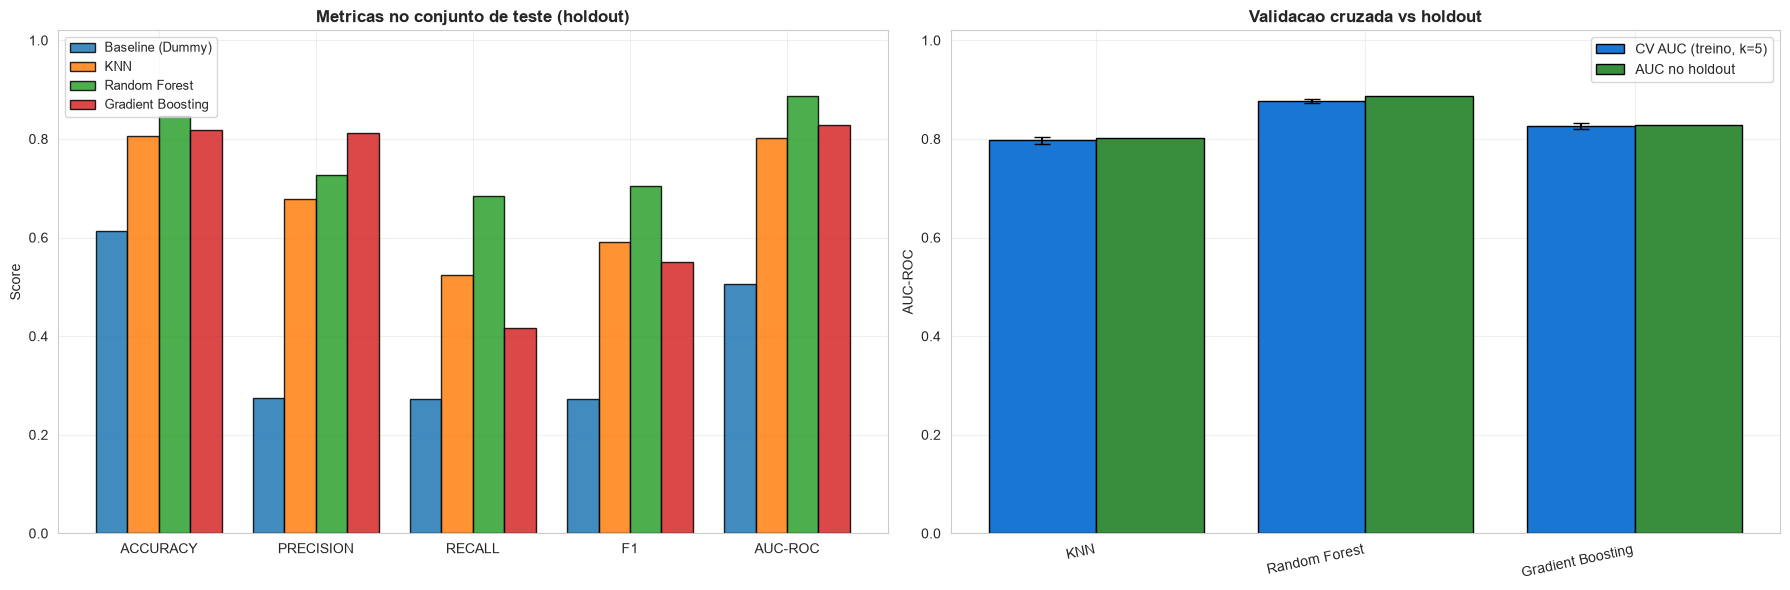

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (a) Metricas lado a lado
metricas = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
xs = np.arange(len(metricas))
largura = 0.2
for i, nome in enumerate(df_result.index):
    axes[0].bar(xs + i * largura, [df_result.loc[nome, m] for m in metricas],
                largura, label=nome, edgecolor='black', alpha=0.85)
axes[0].set_xticks(xs + largura * 1.5)
axes[0].set_xticklabels([m.upper().replace('_', '-') for m in metricas])
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('Metricas no conjunto de teste (holdout)', fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)

# (b) CV vs teste - deteccao de overfitting
sub = df_result.drop(index='Baseline (Dummy)')
x2 = np.arange(len(sub))
axes[1].bar(x2 - 0.2, sub['cv_auc_mean'], 0.4, yerr=sub['cv_auc_std'], capsize=6,
            label='CV AUC (treino, k=5)', color='#1976D2', edgecolor='black')
axes[1].bar(x2 + 0.2, sub['auc_roc'], 0.4, label='AUC no holdout',
            color='#388E3C', edgecolor='black')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(sub.index, rotation=12, ha='right')
axes[1].set_ylim(0, 1.02)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validacao cruzada vs holdout', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/s3_comparativo_modelos.png', dpi=110, bbox_inches='tight')
plt.show()

### 7.2 Curva ROC, curva Precision-Recall e matriz de confusao

Reportamos as duas curvas de proposito. A **ROC** mede o ordenamento de risco
independentemente do limiar e e a metrica que otimizamos no tuning (Secao 8). A
**Precision-Recall** e mais sensivel a classe minoritaria e mostra o custo pratico
de operar em cada nivel de recall. Com desbalanceamento brando (1:2,75) a ROC
continua confiavel; em bases muito mais desbalanceadas a PR seria a escolha
primaria. As duas juntas dizem mais do que qualquer uma sozinha.

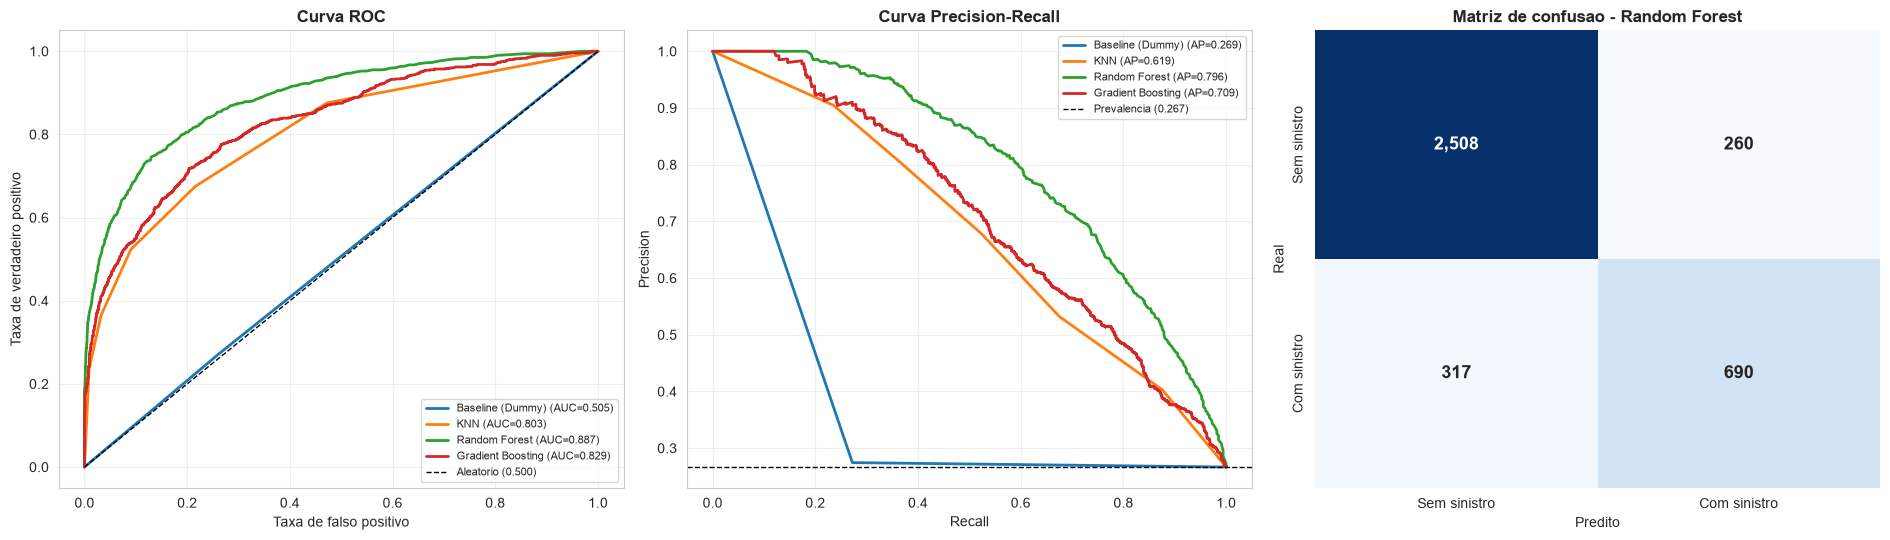

Classification report - Random Forest
              precision    recall  f1-score   support

Sem sinistro     0.8878    0.9061    0.8968      2768
Com sinistro     0.7263    0.6852    0.7052      1007

    accuracy                         0.8472      3775
   macro avg     0.8071    0.7956    0.8010      3775
weighted avg     0.8447    0.8472    0.8457      3775

Leitura de negocio da matriz de confusao:
  Verdadeiro positivo (sinistro previsto e ocorrido) : 690
  Falso negativo (sinistro NAO previsto)             : 317  <- risco nao antecipado
  Falso positivo (alarme falso)                      : 260  <- custo de vistoria
  Verdadeiro negativo                                : 2,508


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (a) ROC
for nome, pipe in pipelines.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, lw=2, label=f"{nome} (AUC={roc_auc_score(y_test, prob):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (0.500)')
axes[0].set_xlabel('Taxa de falso positivo')
axes[0].set_ylabel('Taxa de verdadeiro positivo')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')

# (b) Precision-Recall
for nome, pipe in pipelines.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    pr, rc, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rc, pr, lw=2,
                 label=f"{nome} (AP={average_precision_score(y_test, prob):.3f})")
axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1,
                label=f'Prevalencia ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

# (c) Matriz de confusao do melhor modelo
cm = confusion_matrix(y_test, melhor_pipe.predict(X_test))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[2],
            xticklabels=['Sem sinistro', 'Com sinistro'],
            yticklabels=['Sem sinistro', 'Com sinistro'],
            annot_kws={'fontsize': 13, 'fontweight': 'bold'})
axes[2].set_title(f'Matriz de confusao - {melhor_nome}', fontweight='bold')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.savefig('figures/s3_roc_pr_confusao.png', dpi=110, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Classification report - {melhor_nome}")
print("=" * 60)
print(classification_report(y_test, melhor_pipe.predict(X_test),
                            target_names=['Sem sinistro', 'Com sinistro'], digits=4))
print("Leitura de negocio da matriz de confusao:")
print(f"  Verdadeiro positivo (sinistro previsto e ocorrido) : {tp:,}")
print(f"  Falso negativo (sinistro NAO previsto)             : {fn:,}  <- risco nao antecipado")
print(f"  Falso positivo (alarme falso)                      : {fp:,}  <- custo de vistoria")
print(f"  Verdadeiro negativo                                : {tn:,}")

## 8. Tuning de Hiperparametros

> **Requisito 4 do desafio:** *ajuste de hiperparametros (ex: k no KNN)*

Usamos `GridSearchCV` com **validacao cruzada estratificada k=5 sobre o conjunto
de treino**. O conjunto de teste continua intocado - qualquer escolha de
hiperparametro feita olhando o teste invalidaria a avaliacao final.
A metrica otimizada e o **AUC-ROC**, apropriada para base desbalanceada por
avaliar o ordenamento de risco independentemente do limiar de decisao.

### 8.1 KNN - o efeito do `k` (o exemplo citado no enunciado)

In [20]:
grade_knn = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 41],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan'],
}
gs_knn = GridSearchCV(
    Pipeline([('pre', criar_preprocessador()), ('clf', KNeighborsClassifier())]),
    grade_knn, scoring='roc_auc', cv=cv, n_jobs=-1, return_train_score=True)

t0 = time.time()
gs_knn.fit(X_train, y_train)
print(f"KNN - {len(gs_knn.cv_results_['params'])} combinacoes x {CV_FOLDS} folds "
      f"= {len(gs_knn.cv_results_['params'])*CV_FOLDS} treinos em {time.time()-t0:.0f}s")
print(f"\nMelhores hiperparametros : {gs_knn.best_params_}")
print(f"Melhor AUC na CV         : {gs_knn.best_score_:.4f}")

KNN - 36 combinacoes x 5 folds = 180 treinos em 124s

Melhores hiperparametros : {'clf__metric': 'manhattan', 'clf__n_neighbors': 21, 'clf__weights': 'distance'}
Melhor AUC na CV         : 0.8332


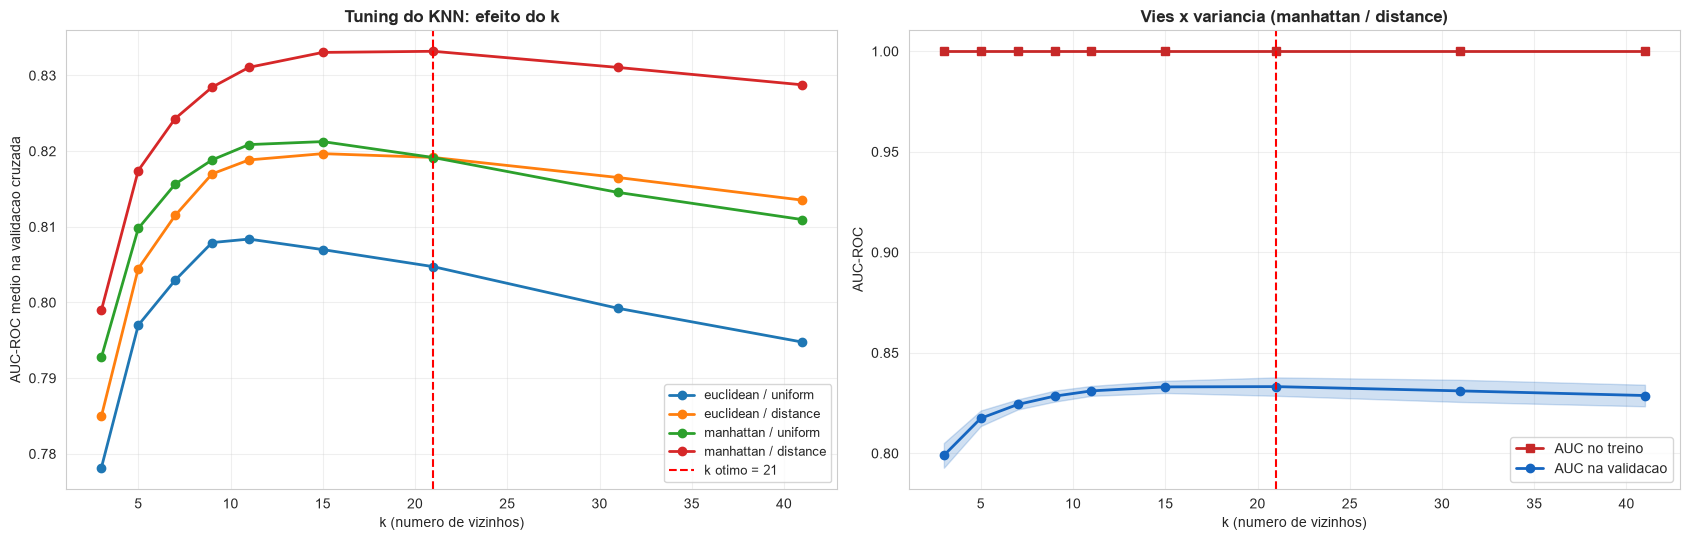

AUC por k (melhor combinacao de metrica e peso):
 k  AUC_treino  AUC_validacao  desvio
 3         1.0         0.7990  0.0061
 5         1.0         0.8174  0.0039
 7         1.0         0.8243  0.0025
 9         1.0         0.8285  0.0027
11         1.0         0.8311  0.0025
15         1.0         0.8330  0.0030
21         1.0         0.8332  0.0046
31         1.0         0.8311  0.0055
41         1.0         0.8288  0.0054


In [21]:
# Curva do k: o classico compromisso vies-variancia
res_knn = pd.DataFrame(gs_knn.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

for metrica in ['euclidean', 'manhattan']:
    for peso in ['uniform', 'distance']:
        m = (res_knn['param_clf__metric'] == metrica) & (res_knn['param_clf__weights'] == peso)
        sub = res_knn[m].sort_values('param_clf__n_neighbors')
        axes[0].plot(sub['param_clf__n_neighbors'].astype(int), sub['mean_test_score'],
                     marker='o', lw=2, label=f'{metrica} / {peso}')
axes[0].axvline(gs_knn.best_params_['clf__n_neighbors'], color='red', ls='--',
                label=f"k otimo = {gs_knn.best_params_['clf__n_neighbors']}")
axes[0].set_xlabel('k (numero de vizinhos)')
axes[0].set_ylabel('AUC-ROC medio na validacao cruzada')
axes[0].set_title('Tuning do KNN: efeito do k', fontweight='bold')
axes[0].legend(fontsize=9)

# Vies-variancia: treino vs validacao na melhor configuracao de metrica/peso
mb = ((res_knn['param_clf__metric'] == gs_knn.best_params_['clf__metric']) &
      (res_knn['param_clf__weights'] == gs_knn.best_params_['clf__weights']))
sb = res_knn[mb].sort_values('param_clf__n_neighbors')
ks = sb['param_clf__n_neighbors'].astype(int)
axes[1].plot(ks, sb['mean_train_score'], marker='s', lw=2, color='#C62828', label='AUC no treino')
axes[1].plot(ks, sb['mean_test_score'], marker='o', lw=2, color='#1565C0', label='AUC na validacao')
axes[1].fill_between(ks, sb['mean_test_score'] - sb['std_test_score'],
                     sb['mean_test_score'] + sb['std_test_score'], alpha=0.2, color='#1565C0')
axes[1].axvline(gs_knn.best_params_['clf__n_neighbors'], color='red', ls='--')
axes[1].set_xlabel('k (numero de vizinhos)')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title(f"Vies x variancia ({gs_knn.best_params_['clf__metric']} / "
                  f"{gs_knn.best_params_['clf__weights']})", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/s3_tuning_knn.png', dpi=110, bbox_inches='tight')
plt.show()

print("AUC por k (melhor combinacao de metrica e peso):")
print(pd.DataFrame({'k': ks.values,
                    'AUC_treino': sb['mean_train_score'].round(4).values,
                    'AUC_validacao': sb['mean_test_score'].round(4).values,
                    'desvio': sb['std_test_score'].round(4).values}).to_string(index=False))

**Leitura do grafico.** A curva de **validacao** (azul) descreve o compromisso
vies-variancia de manual. Com `k` pequeno cada predicao se apoia em pouquissimos
vizinhos e absorve o ruido das apolices individuais - **alta variancia**, e o
AUC de validacao e o mais baixo da serie. Conforme `k` cresce, a vizinhanca
suaviza esse ruido e o AUC sobe ate um pico. Depois dele, vizinhancas grandes
demais passam a misturar apolices dissimilares e o modelo perde poder
discriminante - **alto vies**. O `k` escolhido pela busca esta exatamente no pico.

**Por que a curva de treino (vermelha) fica achatada em 1,0.** E um artefato
esperado de `weights='distance'`: ao pontuar um ponto do proprio treino, ele
aparece como vizinho de si mesmo a distancia zero e recebe peso infinito,
dominando a votacao. O acerto no treino e, portanto, trivialmente perfeito para
**qualquer** `k`. Isso mostra por que a validacao cruzada e indispensavel aqui:
a metrica de treino nao carrega informacao alguma sobre generalizacao neste
modelo, e escolher `k` por ela seria impossivel.

### 8.2 Tuning do Random Forest e do Gradient Boosting

In [22]:
grades = {
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        {'clf__n_estimators':     [200, 400],
         'clf__max_depth':        [None, 12, 20],
         'clf__min_samples_leaf': [1, 5],
         'clf__max_features':     ['sqrt', 0.5]},
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'clf__n_estimators':  [200, 300],
         'clf__learning_rate': [0.05, 0.1],
         'clf__max_depth':     [3, 5],
         'clf__subsample':     [1.0, 0.8]},
    ),
}

buscas = {'KNN': gs_knn}
for nome, (estimador, grade) in grades.items():
    gs = GridSearchCV(Pipeline([('pre', criar_preprocessador()), ('clf', estimador)]),
                      grade, scoring='roc_auc', cv=cv, n_jobs=-1)
    t0 = time.time()
    gs.fit(X_train, y_train)
    buscas[nome] = gs
    print(f"{nome:20s} | {len(gs.cv_results_['params']):3d} combinacoes | "
          f"CV AUC = {gs.best_score_:.4f} | {time.time()-t0:.0f}s")
    print(f"{'':20s}   {gs.best_params_}")

Random Forest        |  24 combinacoes | CV AUC = 0.8827 | 232s
                       {'clf__max_depth': 20, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}


Gradient Boosting    |  16 combinacoes | CV AUC = 0.8668 | 288s
                       {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 300, 'clf__subsample': 0.8}


### 8.3 Impacto do tuning: antes x depois

Reavaliamos cada modelo otimizado **no mesmo holdout**, nunca usado no tuning.

In [23]:
linhas_tuning = []
pipelines_tuned = {}
for nome, gs in buscas.items():
    best = gs.best_estimator_
    pipelines_tuned[nome] = best
    prob = best.predict_proba(X_test)[:, 1]
    pred = best.predict(X_test)
    linhas_tuning.append({
        'modelo': nome,
        'auc_antes':  df_result.loc[nome, 'auc_roc'],
        'auc_depois': roc_auc_score(y_test, prob),
        'f1_antes':   df_result.loc[nome, 'f1'],
        'f1_depois':  f1_score(y_test, pred, zero_division=0),
        'accuracy':   accuracy_score(y_test, pred),
        'precision':  precision_score(y_test, pred, zero_division=0),
        'recall':     recall_score(y_test, pred, zero_division=0),
        'cv_auc':     gs.best_score_,
    })

df_tuning = pd.DataFrame(linhas_tuning).set_index('modelo')
df_tuning['ganho_auc'] = df_tuning['auc_depois'] - df_tuning['auc_antes']

print("=" * 104)
print("IMPACTO DO TUNING - avaliado no holdout")
print("=" * 104)
print(df_tuning[['auc_antes', 'auc_depois', 'ganho_auc', 'f1_antes', 'f1_depois',
                 'accuracy', 'precision', 'recall']].round(4).to_string())
print("=" * 104)

# Novamente: o campeao e eleito pelo AUC da VALIDACAO CRUZADA (coluna cv_auc, vinda
# do GridSearchCV sobre o treino). O holdout so confirma.
melhor_final = df_tuning['cv_auc'].idxmax()
modelo_final = pipelines_tuned[melhor_final]
_ordem_cv = list(df_tuning['cv_auc'].sort_values(ascending=False).index)
_ordem_ho = list(df_tuning['auc_depois'].sort_values(ascending=False).index)
print(f"\n>>> MODELO FINAL (eleito pela CV): {melhor_final}")
print(f"    CV AUC no treino : {df_tuning.loc[melhor_final,'cv_auc']:.4f}")
print(f"    AUC no holdout   : {df_tuning.loc[melhor_final,'auc_depois']:.4f}")
print(f"    F1 no holdout    : {df_tuning.loc[melhor_final,'f1_depois']:.4f}")
print(f"    Hiperparametros  : {buscas[melhor_final].best_params_}")
print(f"    Ordem por CV = {_ordem_cv}")
print(f"    Ordem por holdout = {_ordem_ho}")
print(f"    Coincidem? {'SIM - a escolha nao dependeu do teste' if _ordem_cv == _ordem_ho else 'NAO'}")

IMPACTO DO TUNING - avaliado no holdout
                   auc_antes  auc_depois  ganho_auc  f1_antes  f1_depois  accuracy  precision  recall
modelo                                                                                               
KNN                   0.8029      0.8372     0.0343    0.5908     0.5808    0.8180     0.7532  0.4727
Random Forest         0.8866      0.8922     0.0056    0.7052     0.7134    0.8474     0.7149  0.7120
Gradient Boosting     0.8290      0.8792     0.0502    0.5502     0.6659    0.8472     0.7986  0.5710

>>> MODELO FINAL (eleito pela CV): Random Forest
    CV AUC no treino : 0.8827
    AUC no holdout   : 0.8922
    F1 no holdout    : 0.7134
    Hiperparametros  : {'clf__max_depth': 20, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
    Ordem por CV = ['Random Forest', 'Gradient Boosting', 'KNN']
    Ordem por holdout = ['Random Forest', 'Gradient Boosting', 'KNN']
    Coincidem? SIM - a escolha nao dependeu do te

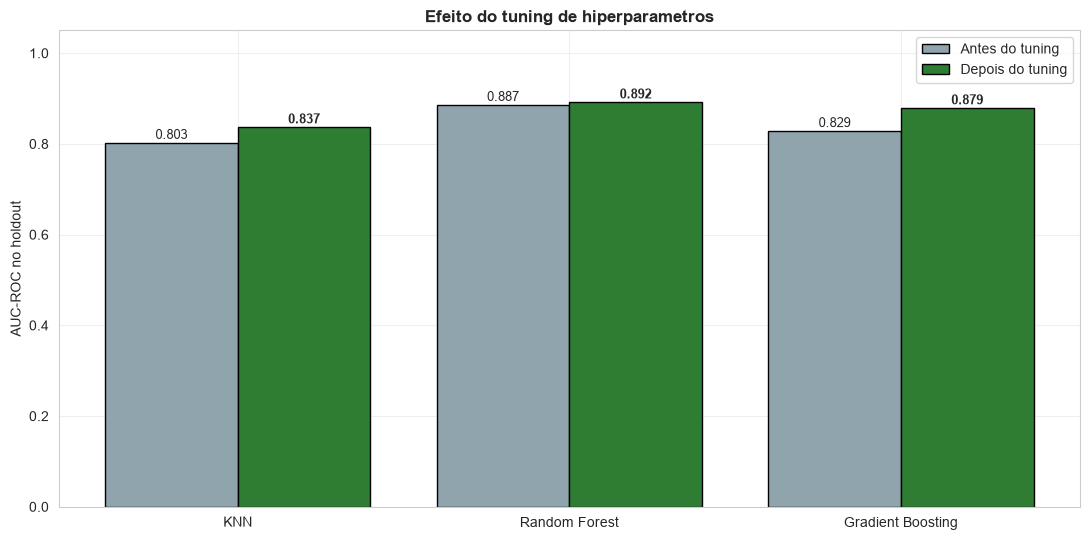

In [24]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(df_tuning))
ax.bar(x - 0.2, df_tuning['auc_antes'], 0.4, label='Antes do tuning',
       color='#90A4AE', edgecolor='black')
ax.bar(x + 0.2, df_tuning['auc_depois'], 0.4, label='Depois do tuning',
       color='#2E7D32', edgecolor='black')
for i, (a, d) in enumerate(zip(df_tuning['auc_antes'], df_tuning['auc_depois'])):
    ax.text(i - 0.2, a + 0.008, f'{a:.3f}', ha='center', fontsize=9)
    ax.text(i + 0.2, d + 0.008, f'{d:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_tuning.index)
ax.set_ylabel('AUC-ROC no holdout')
ax.set_ylim(0, 1.05)
ax.set_title('Efeito do tuning de hiperparametros', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/s3_impacto_tuning.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Tarefa B - Regressao da Severidade

> **Requisito 3 do desafio:** *metricas de regressao - MAE, RMSE, R2*

Prever *se* havera sinistro nao basta para precificar: e preciso estimar
**quanto** custa. Modelamos aqui `VL_INDENIZACAO` (em R$) sobre as
**5.033 apolices que efetivamente sinistraram**.

Este e o segundo fator da decomposicao atuarial
`Premio Puro = Frequencia (Secao 6) x Severidade (esta secao)`.

In [25]:
df_sev = df[df['TEVE_SINISTRO'] == 1].copy()
# Fatiamos X (e nao df[FEATURES]) para herdar o FREQ_MUNICIPIO ajustado no treino
# da Secao 5.3 - assim classificacao e regressao usam a MESMA definicao da feature.
X_sev = X.loc[df_sev.index].copy()
y_sev = df_sev['VL_INDENIZACAO'].copy()

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_sev, y_sev, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print("HOLDOUT DA REGRESSAO (apolices sinistradas)")
print("=" * 62)
print(f"  Treino : {Xs_train.shape[0]:,} | Teste : {Xs_test.shape[0]:,}")
print(f"\n  Indenizacao no treino: media R$ {ys_train.mean():,.0f} | "
      f"mediana R$ {ys_train.median():,.0f}")
print(f"  Indenizacao no teste : media R$ {ys_test.mean():,.0f} | "
      f"mediana R$ {ys_test.median():,.0f}")
print(f"  Assimetria (skew) do target: {y_sev.skew():.2f} "
      f"-> cauda longa a direita, tipica de severidade em seguros")

_zeros = int((y_sev == 0).sum())
print(f"\n[COMPOSICAO DO ALVO] {_zeros:,} das {len(y_sev):,} apolices sinistradas "
      f"({_zeros/len(y_sev)*100:.1f}%) tem indenizacao apurada de R$ 0.")
print("  Sao sinistros com evento registrado mas sem pagamento. Mantivemos essas")
print("  linhas: exclui-las mudaria a pergunta de 'quanto custa um sinistro' para")
print("  'quanto custa um sinistro que gerou pagamento'. A consequencia e que o")
print("  modelo precisa aprender duas coisas ao mesmo tempo - se havera pagamento e")
print("  de quanto ele sera -, o que limita o R2 alcancavel e e uma explicacao")
print("  concorrente, alem da falta de dados de intensidade do evento climatico.")

HOLDOUT DA REGRESSAO (apolices sinistradas)
  Treino : 4,026 | Teste : 1,007

  Indenizacao no treino: media R$ 61,592 | mediana R$ 27,873
  Indenizacao no teste : media R$ 61,193 | mediana R$ 27,101
  Assimetria (skew) do target: 4.79 -> cauda longa a direita, tipica de severidade em seguros

[COMPOSICAO DO ALVO] 904 das 5,033 apolices sinistradas (18.0%) tem indenizacao apurada de R$ 0.
  Sao sinistros com evento registrado mas sem pagamento. Mantivemos essas
  linhas: exclui-las mudaria a pergunta de 'quanto custa um sinistro' para
  'quanto custa um sinistro que gerou pagamento'. A consequencia e que o
  modelo precisa aprender duas coisas ao mesmo tempo - se havera pagamento e
  de quanto ele sera -, o que limita o R2 alcancavel e e uma explicacao
  concorrente, alem da falta de dados de intensidade do evento climatico.


In [26]:
regressores = {
    'Baseline (media)':  DummyRegressor(strategy='mean'),
    'KNN':               KNeighborsRegressor(n_neighbors=10, weights='distance'),
    'Random Forest':     RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

linhas_reg, pipelines_reg = [], {}
print("=" * 88)
print("REGRESSAO DA SEVERIDADE - metricas no holdout")
print("=" * 88)
for nome, reg in regressores.items():
    pipe = Pipeline([('pre', criar_preprocessador()), ('reg', reg)])
    t0 = time.time()
    pipe.fit(Xs_train, ys_train)
    tempo = time.time() - t0
    pred = pipe.predict(Xs_test)

    mae = mean_absolute_error(ys_test, pred)
    rmse = float(np.sqrt(mean_squared_error(ys_test, pred)))
    r2 = r2_score(ys_test, pred)
    # CV no TREINO: e por ela que o campeao sera eleito, nao pelo holdout.
    cv_r2 = cross_val_score(pipe, Xs_train, ys_train,
                            cv=KFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
                            scoring='r2', n_jobs=-1)
    linhas_reg.append({'modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                       'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(), 'tempo_s': tempo})
    pipelines_reg[nome] = pipe
    print(f"  {nome:20s} MAE = R$ {mae:>11,.0f} | RMSE = R$ {rmse:>11,.0f} | "
          f"R2 = {r2:>7.4f} | CV R2 = {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

df_reg = pd.DataFrame(linhas_reg).set_index('modelo')
melhor_reg = df_reg.drop(index='Baseline (media)')['cv_r2_mean'].idxmax()
print("=" * 88)
print(f">>> MELHOR REGRESSOR (eleito pela CV): {melhor_reg}")
print(f"    CV R2 no treino : {df_reg.loc[melhor_reg,'cv_r2_mean']:.4f} "
      f"+/- {df_reg.loc[melhor_reg,'cv_r2_std']:.4f}")
print(f"    R2 no holdout   : {df_reg.loc[melhor_reg,'R2']:.4f}")
print(f">>> Reducao de MAE sobre o baseline: "
      f"R$ {df_reg.loc['Baseline (media)','MAE'] - df_reg.loc[melhor_reg,'MAE']:,.0f} "
      f"({(1 - df_reg.loc[melhor_reg,'MAE']/df_reg.loc['Baseline (media)','MAE'])*100:.1f}%)")
print(f"\n[RESSALVA] O R2 de um split unico e instavel num alvo com cauda pesada.")
print(f"           O desvio da CV ({df_reg.loc[melhor_reg,'cv_r2_std']:.4f}) e a medida")
print(f"           honesta dessa incerteza - o valor pontual do holdout nao deve ser")
print(f"           lido como precisao de 4 casas.")

REGRESSAO DA SEVERIDADE - metricas no holdout
  Baseline (media)     MAE = R$      61,397 | RMSE = R$     115,218 | R2 = -0.0000 | CV R2 = -0.0001 +/- 0.0001


  KNN                  MAE = R$      44,180 | RMSE = R$      95,726 | R2 =  0.3097 | CV R2 = 0.4219 +/- 0.0583


  Random Forest        MAE = R$      43,802 | RMSE = R$      91,291 | R2 =  0.3722 | CV R2 = 0.4328 +/- 0.0784


  Gradient Boosting    MAE = R$      46,289 | RMSE = R$      97,177 | R2 =  0.2886 | CV R2 = 0.3806 +/- 0.0523
>>> MELHOR REGRESSOR (eleito pela CV): Random Forest
    CV R2 no treino : 0.4328 +/- 0.0784
    R2 no holdout   : 0.3722
>>> Reducao de MAE sobre o baseline: R$ 17,595 (28.7%)

[RESSALVA] O R2 de um split unico e instavel num alvo com cauda pesada.
           O desvio da CV (0.0784) e a medida
           honesta dessa incerteza - o valor pontual do holdout nao deve ser
           lido como precisao de 4 casas.


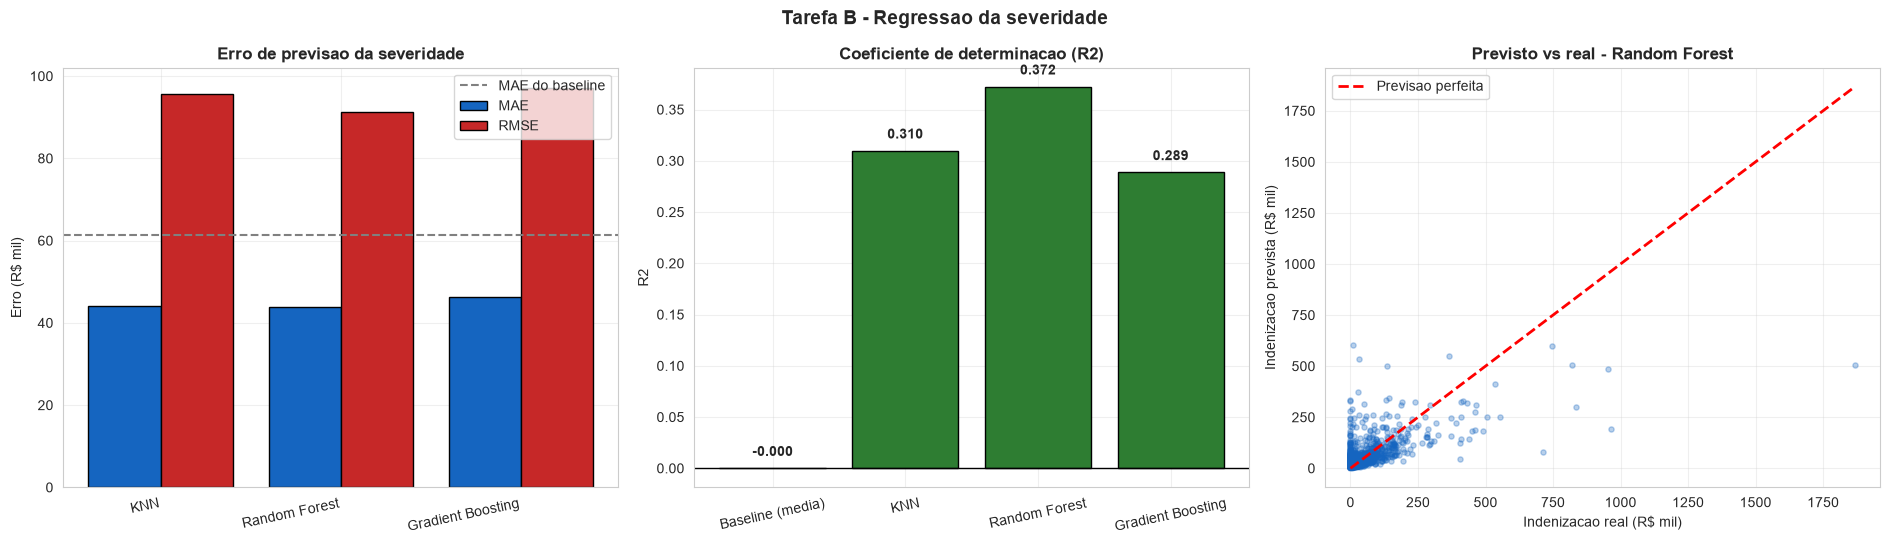


Interpretacao: um R2 de 0.37 significa que o modelo
explica 37% da variancia do valor indenizado.
Severidade e reconhecidamente mais dificil que frequencia: o valor pago depende
da INTENSIDADE do evento climatico (quantos mm de chuva faltaram, quantos graus
de geada), informacao que nao esta na apolice. Ainda assim, o modelo reduz o erro
medio de forma relevante frente ao baseline que sempre chuta a media.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (a) MAE e RMSE
sub_r = df_reg.drop(index='Baseline (media)')
x = np.arange(len(sub_r))
axes[0].bar(x - 0.2, sub_r['MAE'] / 1000, 0.4, label='MAE', color='#1565C0', edgecolor='black')
axes[0].bar(x + 0.2, sub_r['RMSE'] / 1000, 0.4, label='RMSE', color='#C62828', edgecolor='black')
axes[0].axhline(df_reg.loc['Baseline (media)', 'MAE'] / 1000, color='gray', ls='--',
                label='MAE do baseline')
axes[0].set_xticks(x); axes[0].set_xticklabels(sub_r.index, rotation=12, ha='right')
axes[0].set_ylabel('Erro (R$ mil)')
axes[0].set_title('Erro de previsao da severidade', fontweight='bold')
axes[0].legend()

# (b) R2
cores = ['#2E7D32' if v > 0 else '#C62828' for v in df_reg['R2']]
axes[1].bar(df_reg.index, df_reg['R2'], color=cores, edgecolor='black')
axes[1].axhline(0, color='black', lw=1)
for i, v in enumerate(df_reg['R2']):
    axes[1].text(i, v + 0.012, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].set_ylabel('R2')
axes[1].set_title('Coeficiente de determinacao (R2)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=12)

# (c) Previsto vs real
pred_best = pipelines_reg[melhor_reg].predict(Xs_test)
axes[2].scatter(ys_test / 1000, pred_best / 1000, alpha=0.3, s=14, color='#1565C0')
lim = max(ys_test.max(), pred_best.max()) / 1000
axes[2].plot([0, lim], [0, lim], 'r--', lw=2, label='Previsao perfeita')
axes[2].set_xlabel('Indenizacao real (R$ mil)')
axes[2].set_ylabel('Indenizacao prevista (R$ mil)')
axes[2].set_title(f'Previsto vs real - {melhor_reg}', fontweight='bold')
axes[2].legend()

plt.suptitle('Tarefa B - Regressao da severidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_regressao_severidade.png', dpi=110, bbox_inches='tight')
plt.show()

print(f"\nInterpretacao: um R2 de {df_reg.loc[melhor_reg,'R2']:.2f} significa que o modelo")
print(f"explica {df_reg.loc[melhor_reg,'R2']*100:.0f}% da variancia do valor indenizado.")
print("Severidade e reconhecidamente mais dificil que frequencia: o valor pago depende")
print("da INTENSIDADE do evento climatico (quantos mm de chuva faltaram, quantos graus")
print("de geada), informacao que nao esta na apolice. Ainda assim, o modelo reduz o erro")
print("medio de forma relevante frente ao baseline que sempre chuta a media.")

## 10. Interpretacao: quais variaveis mais impactam o risco?

> **Requisito 5 do desafio:** *quais variaveis mais impactam o risco?*

Nenhuma metrica de importancia isolada e confiavel: cada uma tem um vies
conhecido. Por isso usamos **tres leituras complementares**.

1. **Feature importance (impureza)** - nativa das arvores e barata, mas
   tendenciosa a favor de variaveis continuas de alta cardinalidade e calculada
   sobre o conjunto de treino.
2. **Permutation importance individual** - embaralha uma coluna por vez **no
   holdout** e mede quanto o AUC cai. E agnostica ao modelo e avalia o impacto
   sobre a metrica que interessa, mas **subestima variaveis redundantes**: se
   duas colunas carregam a mesma informacao, destruir uma nao machuca.
3. **Permutation importance por bloco** - embaralha grupos de colunas
   correlacionadas de uma vez, corrigindo justamente essa diluicao.

A conclusao final (Secao 14.2) sai da convergencia entre as tres, cruzada com a
evidencia descritiva da Secao 10.4.

### 10.1 Feature importance das arvores

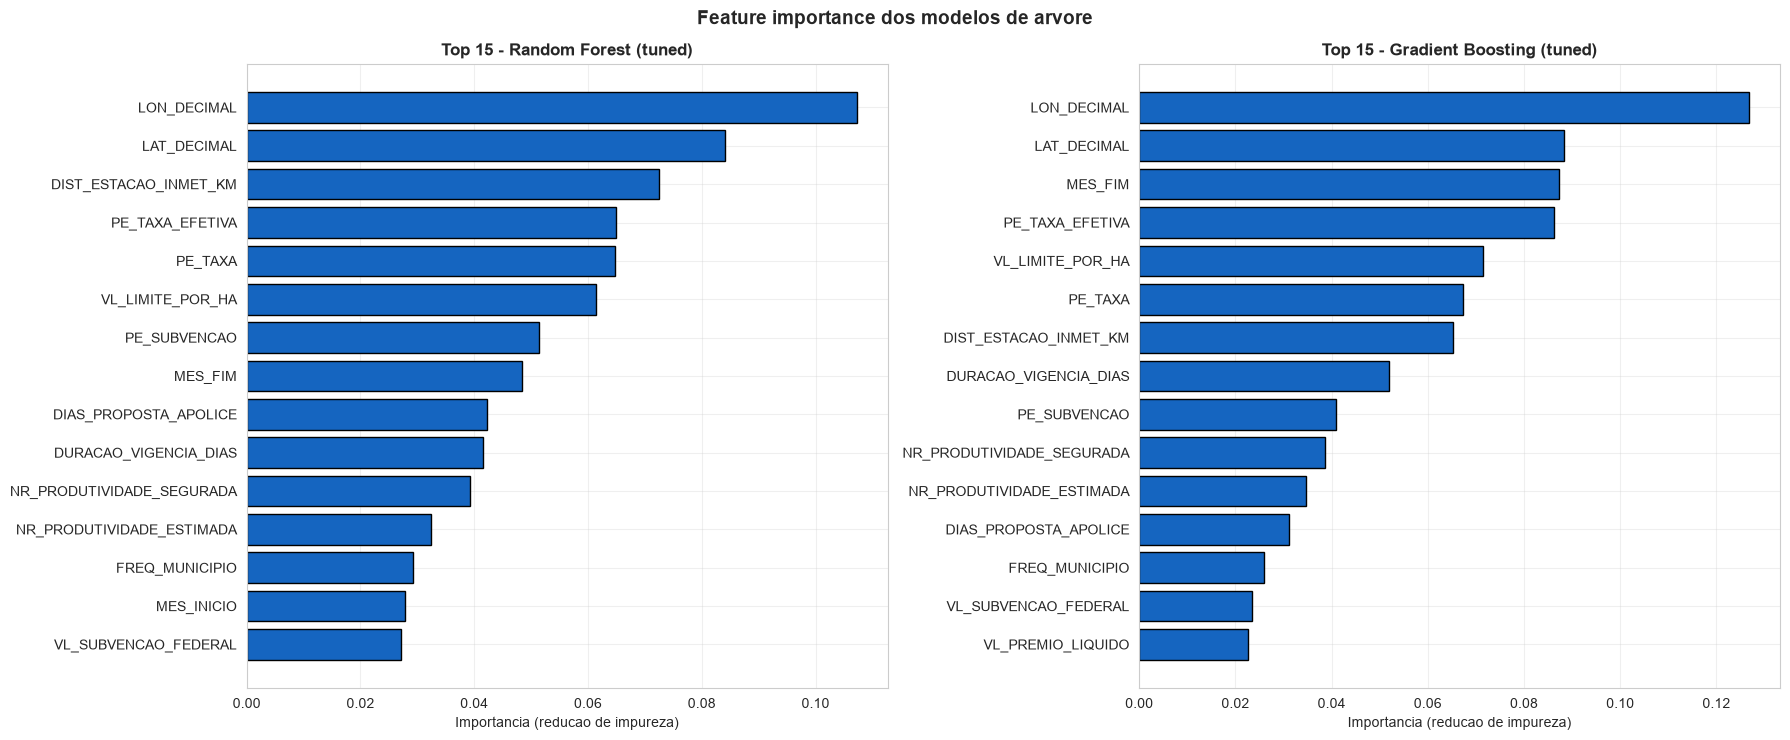

Top 15 por importancia de impureza (media dos dois modelos):
                           Random Forest  Gradient Boosting   media
LON_DECIMAL                       0.1073             0.1269  0.1171
LAT_DECIMAL                       0.0840             0.0882  0.0861
PE_TAXA_EFETIVA                   0.0649             0.0863  0.0756
DIST_ESTACAO_INMET_KM             0.0725             0.0652  0.0689
MES_FIM                           0.0484             0.0872  0.0678
VL_LIMITE_POR_HA                  0.0614             0.0715  0.0665
PE_TAXA                           0.0647             0.0672  0.0660
DURACAO_VIGENCIA_DIAS             0.0416             0.0519  0.0467
PE_SUBVENCAO                      0.0515             0.0409  0.0462
NR_PRODUTIVIDADE_SEGURADA         0.0393             0.0387  0.0390
DIAS_PROPOSTA_APOLICE             0.0423             0.0312  0.0368
NR_PRODUTIVIDADE_ESTIMADA         0.0325             0.0346  0.0335
FREQ_MUNICIPIO                    0.0292             0.

In [28]:
def nomes_legiveis(nomes):
    """Remove os prefixos gerados pelo ColumnTransformer."""
    return [n.replace('num__', '').replace('cat__', '') for n in nomes]


nomes_pos = nomes_legiveis(list(modelo_final.named_steps['pre'].get_feature_names_out()))

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
importancias = {}
for i, nome in enumerate(['Random Forest', 'Gradient Boosting']):
    pipe = pipelines_tuned[nome]
    imp = pipe.named_steps['clf'].feature_importances_
    cols = nomes_legiveis(list(pipe.named_steps['pre'].get_feature_names_out()))
    s = pd.Series(imp, index=cols).sort_values(ascending=False)
    importancias[nome] = s
    top = s.head(15)[::-1]
    axes[i].barh(top.index, top.values, color='#1565C0', edgecolor='black')
    axes[i].set_title(f'Top 15 - {nome} (tuned)', fontweight='bold')
    axes[i].set_xlabel('Importancia (reducao de impureza)')

plt.suptitle('Feature importance dos modelos de arvore', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()

# Ranking lado a lado, para conferencia numerica (o grafico mostra so o top 15)
comp_imp = pd.DataFrame({
    'Random Forest': importancias['Random Forest'],
    'Gradient Boosting': importancias['Gradient Boosting'],
}).fillna(0)
comp_imp['media'] = comp_imp.mean(axis=1)
print("Top 15 por importancia de impureza (media dos dois modelos):")
print(comp_imp.sort_values('media', ascending=False).head(15).round(4).to_string())

### 10.2 Permutation importance (no holdout)

Permutation importance calculada em 21s (26 features x 10 repeticoes)


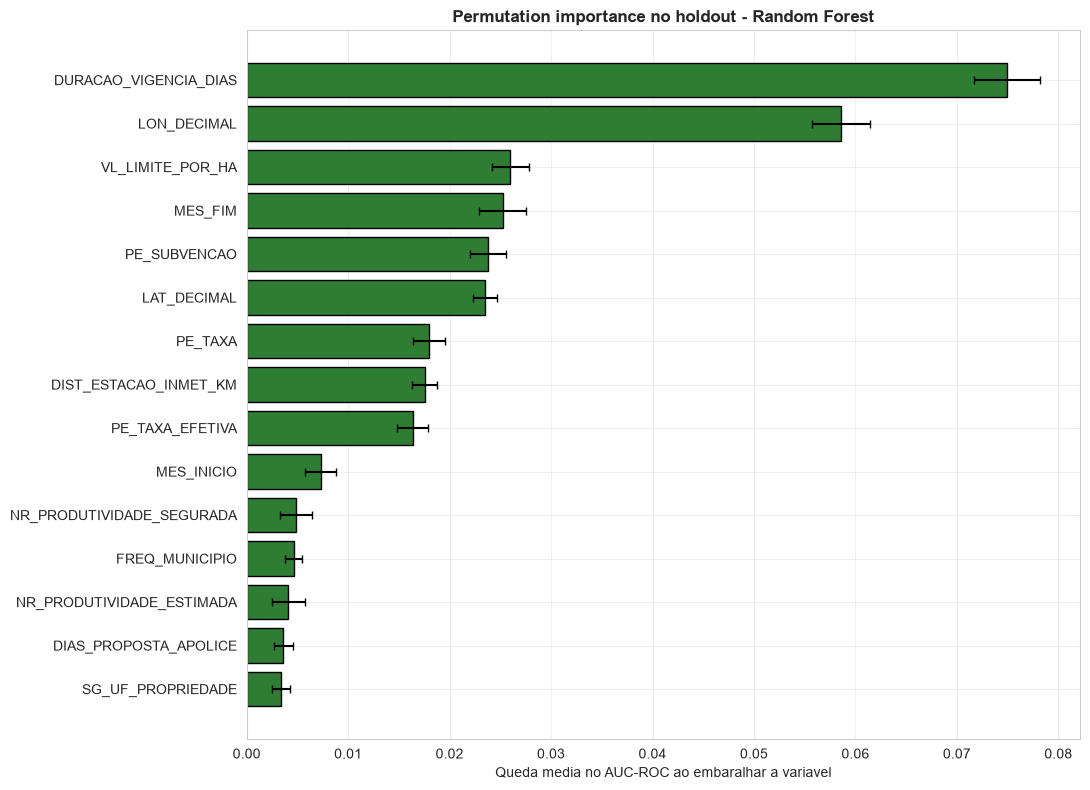

Ranking completo (queda de AUC ao embaralhar):
                           queda_AUC  desvio
DURACAO_VIGENCIA_DIAS         0.0749  0.0033
LON_DECIMAL                   0.0586  0.0029
VL_LIMITE_POR_HA              0.0260  0.0018
MES_FIM                       0.0252  0.0023
PE_SUBVENCAO                  0.0238  0.0018
LAT_DECIMAL                   0.0235  0.0012
PE_TAXA                       0.0180  0.0016
DIST_ESTACAO_INMET_KM         0.0175  0.0013
PE_TAXA_EFETIVA               0.0164  0.0015
MES_INICIO                    0.0073  0.0015
NR_PRODUTIVIDADE_SEGURADA     0.0049  0.0016
FREQ_MUNICIPIO                0.0046  0.0008
NR_PRODUTIVIDADE_ESTIMADA     0.0041  0.0016
DIAS_PROPOSTA_APOLICE         0.0036  0.0010
SG_UF_PROPRIEDADE             0.0034  0.0009
CONAB_AREA_CANA_UF            0.0034  0.0007
GAP_PRODUTIVIDADE             0.0026  0.0007
NivelDeCobertura              0.0023  0.0006
VL_SUBVENCAO_FEDERAL          0.0012  0.0006
NM_CULTURA_GLOBAL             0.0011  0.0010
NM_CLASS

In [29]:
t0 = time.time()
perm = permutation_importance(modelo_final, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1)
print(f"Permutation importance calculada em {time.time()-t0:.0f}s "
      f"({len(FEATURES)} features x 10 repeticoes)")

perm_s = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
perm_sd = pd.Series(perm.importances_std, index=FEATURES)

fig, ax = plt.subplots(figsize=(11, 8))
top_p = perm_s.head(15)[::-1]
ax.barh(top_p.index, top_p.values, xerr=perm_sd[top_p.index].values,
        color='#2E7D32', edgecolor='black', capsize=3)
ax.set_xlabel('Queda media no AUC-ROC ao embaralhar a variavel')
ax.set_title(f'Permutation importance no holdout - {melhor_final}', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_permutation_importance.png', dpi=110, bbox_inches='tight')
plt.show()

print("Ranking completo (queda de AUC ao embaralhar):")
print(pd.DataFrame({'queda_AUC': perm_s.round(4),
                    'desvio': perm_sd[perm_s.index].round(4)}).to_string())

### 10.3 Importancia por bloco de informacao

#### Por que o ranking acima precisa de um cuidado: diluicao entre variaveis correlacionadas

A permutation importance responde *"quanto o modelo perde se eu destruir**apenas
esta** coluna?"*. Quando duas colunas carregam a mesma informacao, embaralhar uma
delas nao machuca - o modelo simplesmente recorre a outra. As duas aparecem entao
como irrelevantes, mesmo sendo importantes em conjunto.

Nossa matriz tem redundancia **proposital**, e ela aparece com clareza no ranking:

- `NR_AREA_TOTAL` e `LOG_AREA` sao a mesma variavel em escalas diferentes:
  ambas ficam em torno de zero.
- `VL_LIMITE_GARANTIA` e `LOG_LIMITE`: mesma situacao.
- `CONAB_AREA_CANA_UF` e constante dentro de cada UF, portanto redundante com
  `SG_UF_PROPRIEDADE`: embaralhar uma nao machuca enquanto a outra permanece.
- `NM_CULTURA_GLOBAL` aparece com importancia baixa por um motivo mais sutil:
  a cultura **determina o calendario agricola**. Soja, milho 2a safra e trigo tem
  janelas de vigencia e meses de plantio distintos, entao `DURACAO_VIGENCIA_DIAS`,
  `MES_INICIO` e `MES_FIM` ja carregam quase toda a informacao da cultura.

Para medir o efeito real de cada **bloco de informacao**, embaralhamos grupos
inteiros de colunas de uma vez.

AUC do modelo intacto: 0.8922

IMPORTANCIA POR BLOCO DE INFORMACAO (grupo embaralhado em conjunto)
                               n_variaveis  queda_AUC  desvio
grupo                                                        
Cultura e calendario agricola            4     0.2419  0.0047
Geografia                                6     0.1711  0.0067
Precificacao e cobertura                 4     0.1103  0.0056
Exposicao financeira                     5     0.0360  0.0034
Produtividade contratada                 3     0.0241  0.0020
Processo e tipo de produto               2     0.0038  0.0011
Escala da operacao                       2    -0.0000  0.0010


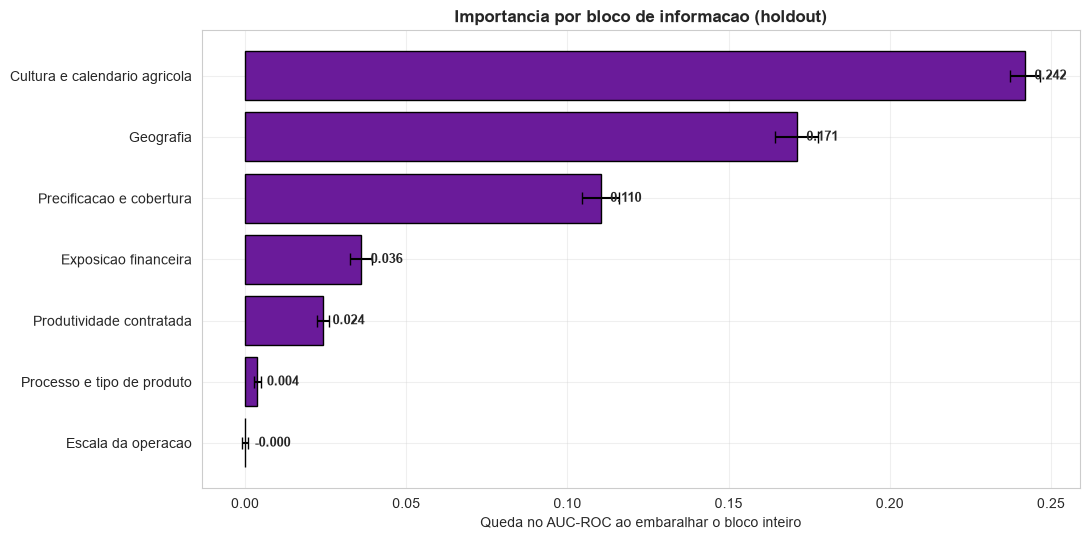

In [30]:
GRUPOS = {
    'Cultura e calendario agricola': ['NM_CULTURA_GLOBAL', 'MES_INICIO', 'MES_FIM',
                                      'DURACAO_VIGENCIA_DIAS'],
    'Geografia':                     ['LAT_DECIMAL', 'LON_DECIMAL', 'SG_UF_PROPRIEDADE',
                                      'FREQ_MUNICIPIO', 'DIST_ESTACAO_INMET_KM',
                                      'CONAB_AREA_CANA_UF'],
    'Precificacao e cobertura':      ['PE_TAXA', 'PE_TAXA_EFETIVA', 'PE_SUBVENCAO',
                                      'NivelDeCobertura'],
    'Exposicao financeira':          ['VL_LIMITE_GARANTIA', 'LOG_LIMITE', 'VL_LIMITE_POR_HA',
                                      'VL_PREMIO_LIQUIDO', 'VL_SUBVENCAO_FEDERAL'],
    'Produtividade contratada':      ['NR_PRODUTIVIDADE_ESTIMADA', 'NR_PRODUTIVIDADE_SEGURADA',
                                      'GAP_PRODUTIVIDADE'],
    'Escala da operacao':            ['NR_AREA_TOTAL', 'LOG_AREA'],
    'Processo e tipo de produto':    ['DIAS_PROPOSTA_APOLICE', 'NM_CLASSIF_PRODUTO'],
}

auc_base = roc_auc_score(y_test, modelo_final.predict_proba(X_test)[:, 1])
rng = np.random.default_rng(RANDOM_STATE)
N_REPETICOES = 10

linhas_grupo = []
for grupo, colunas in GRUPOS.items():
    quedas = []
    for _ in range(N_REPETICOES):
        X_emb = X_test.copy()
        ordem = rng.permutation(len(X_emb))          # a MESMA permutacao para o grupo,
        for c in colunas:                            # preservando a correlacao interna
            X_emb[c] = X_emb[c].to_numpy()[ordem]
        quedas.append(auc_base - roc_auc_score(y_test, modelo_final.predict_proba(X_emb)[:, 1]))
    linhas_grupo.append({'grupo': grupo, 'n_variaveis': len(colunas),
                         'queda_AUC': np.mean(quedas), 'desvio': np.std(quedas)})

df_grupos = pd.DataFrame(linhas_grupo).set_index('grupo').sort_values('queda_AUC', ascending=False)
print(f"AUC do modelo intacto: {auc_base:.4f}\n")
print("IMPORTANCIA POR BLOCO DE INFORMACAO (grupo embaralhado em conjunto)")
print("=" * 78)
print(df_grupos.round(4).to_string())
print("=" * 78)

fig, ax = plt.subplots(figsize=(11, 5.5))
d = df_grupos.sort_values('queda_AUC')
ax.barh(d.index, d['queda_AUC'], xerr=d['desvio'], color='#6A1B9A',
        edgecolor='black', capsize=4)
for i, v in enumerate(d['queda_AUC']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Queda no AUC-ROC ao embaralhar o bloco inteiro')
ax.set_title('Importancia por bloco de informacao (holdout)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_importancia_grupos.png', dpi=110, bbox_inches='tight')
plt.show()

### 10.4 Evidencia de negocio por tras das variaveis do topo

As metricas de importancia dizem *quais* variaveis pesam. Abaixo mostramos
*como* elas se comportam, para que a leitura seja acionavel pela area tecnica.

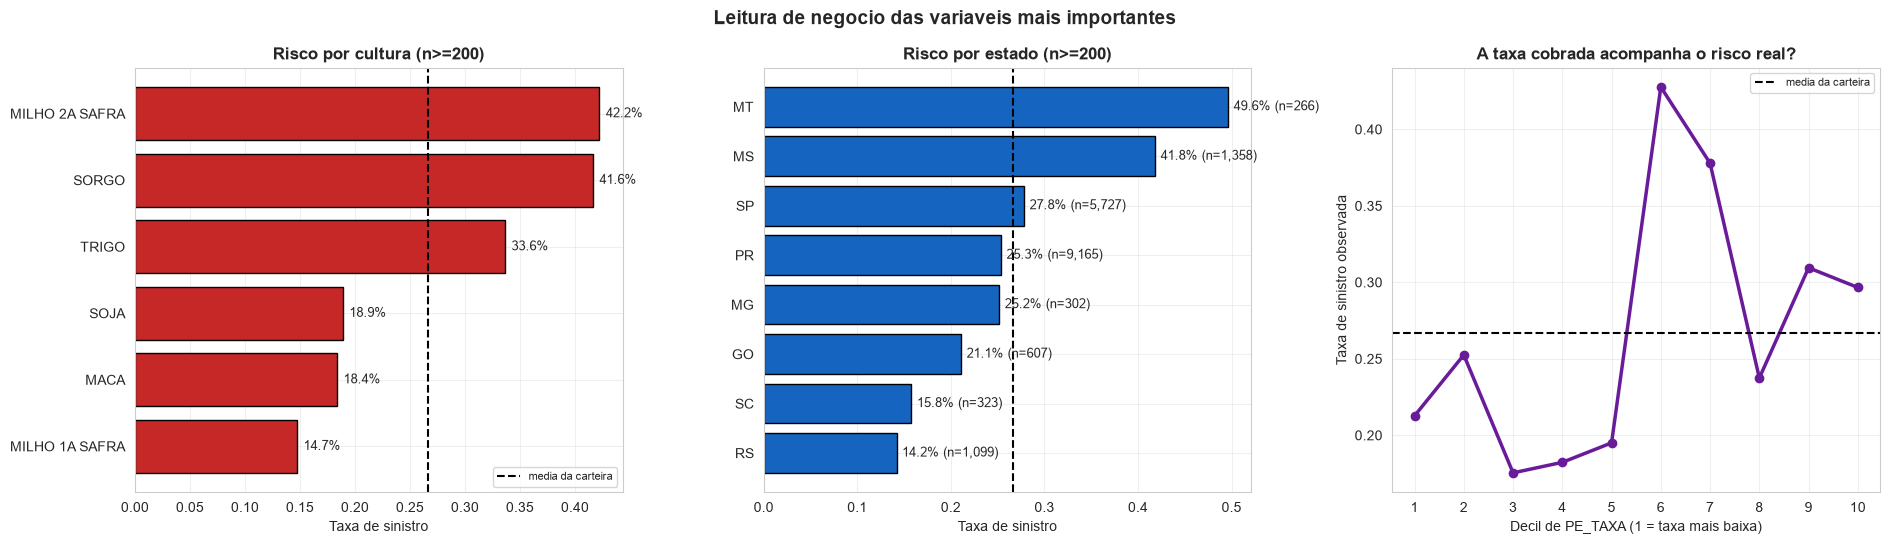

Correlacao entre a taxa cobrada (PE_TAXA) e o sinistro observado: 0.0734
Risco no decil de menor taxa : 21.3%
Risco no decil de maior taxa : 29.7%

Taxa de sinistro por CULTURA (n>=200):
                   taxa_sinistro      n
NM_CULTURA_GLOBAL                      
MILHO 2A SAFRA              42.2   5325
SORGO                       41.6    245
TRIGO                       33.6   1344
SOJA                        18.9  11163
MACA                        18.4    294
MILHO 1A SAFRA              14.7    353

Taxa de sinistro por UF (n>=200):
                   taxa_sinistro     n
SG_UF_PROPRIEDADE                     
MT                          49.6   266
MS                          41.8  1358
SP                          27.8  5727
PR                          25.3  9165
MG                          25.2   302
GO                          21.1   607
SC                          15.8   323
RS                          14.2  1099


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (a) Taxa de sinistro por cultura
g = (df.groupby('NM_CULTURA_GLOBAL')
       .agg(taxa=('TEVE_SINISTRO', 'mean'), n=('TEVE_SINISTRO', 'size'))
       .query('n >= 200').sort_values('taxa'))
axes[0].barh(g.index, g['taxa'], color='#C62828', edgecolor='black')
axes[0].axvline(df['TEVE_SINISTRO'].mean(), color='black', ls='--', label='media da carteira')
for i, (t, n) in enumerate(zip(g['taxa'], g['n'])):
    axes[0].text(t + 0.006, i, f'{t*100:.1f}%', va='center', fontsize=9)
axes[0].set_title('Risco por cultura (n>=200)', fontweight='bold')
axes[0].set_xlabel('Taxa de sinistro'); axes[0].legend(fontsize=8)

# (b) Taxa de sinistro por UF
g2 = (df.groupby('SG_UF_PROPRIEDADE')
        .agg(taxa=('TEVE_SINISTRO', 'mean'), n=('TEVE_SINISTRO', 'size'))
        .query('n >= 200').sort_values('taxa'))
axes[1].barh(g2.index, g2['taxa'], color='#1565C0', edgecolor='black')
axes[1].axvline(df['TEVE_SINISTRO'].mean(), color='black', ls='--')
for i, (t, n) in enumerate(zip(g2['taxa'], g2['n'])):
    axes[1].text(t + 0.006, i, f'{t*100:.1f}% (n={n:,})', va='center', fontsize=9)
axes[1].set_title('Risco por estado (n>=200)', fontweight='bold')
axes[1].set_xlabel('Taxa de sinistro')

# (c) Taxa de sinistro por decil da taxa cobrada
df['_decil_taxa'] = pd.qcut(df['PE_TAXA'], 10, labels=False, duplicates='drop')
g3 = df.groupby('_decil_taxa')['TEVE_SINISTRO'].mean()
axes[2].plot(g3.index + 1, g3.values, marker='o', lw=2.5, color='#6A1B9A')
axes[2].axhline(df['TEVE_SINISTRO'].mean(), color='black', ls='--', label='media da carteira')
axes[2].set_xlabel('Decil de PE_TAXA (1 = taxa mais baixa)')
axes[2].set_ylabel('Taxa de sinistro observada')
axes[2].set_title('A taxa cobrada acompanha o risco real?', fontweight='bold')
axes[2].set_xticks(range(1, 11)); axes[2].legend(fontsize=8)

plt.suptitle('Leitura de negocio das variaveis mais importantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_insights_negocio.png', dpi=110, bbox_inches='tight')
plt.show()

corr_taxa = df[['PE_TAXA', 'TEVE_SINISTRO']].corr().iloc[0, 1]
print(f"Correlacao entre a taxa cobrada (PE_TAXA) e o sinistro observado: {corr_taxa:.4f}")
print(f"Risco no decil de menor taxa : {g3.iloc[0]*100:.1f}%")
print(f"Risco no decil de maior taxa : {g3.iloc[-1]*100:.1f}%")
df.drop(columns=['_decil_taxa'], inplace=True)

# Os mesmos numeros em texto, para que as conclusoes da Secao 14.2 nao dependam
# de o leitor conseguir ler os rotulos dentro da figura.
print("\nTaxa de sinistro por CULTURA (n>=200):")
print((df.groupby('NM_CULTURA_GLOBAL')
         .agg(taxa_sinistro=('TEVE_SINISTRO', 'mean'), n=('TEVE_SINISTRO', 'size'))
         .query('n >= 200').sort_values('taxa_sinistro', ascending=False)
         .assign(taxa_sinistro=lambda d: (d.taxa_sinistro * 100).round(1))).to_string())
print("\nTaxa de sinistro por UF (n>=200):")
print((df.groupby('SG_UF_PROPRIEDADE')
         .agg(taxa_sinistro=('TEVE_SINISTRO', 'mean'), n=('TEVE_SINISTRO', 'size'))
         .query('n >= 200').sort_values('taxa_sinistro', ascending=False)
         .assign(taxa_sinistro=lambda d: (d.taxa_sinistro * 100).round(1))).to_string())

## 11. Validacao Temporal (out-of-time)

O holdout aleatorio exigido pelo desafio responde: *"o modelo generaliza para
apolices novas do mesmo periodo historico?"*. Mas o uso real e outro: treinar
com o passado e prever a **safra seguinte**. Testamos esse cenario treinando
com 2019-2023 e prevendo 2024.

Esta secao vai alem do exigido e produz o achado mais importante do trabalho.

In [32]:
mask_tr = df['ANO_APOLICE'] <= 2023
mask_te = df['ANO_APOLICE'] == 2024

print("SPLIT TEMPORAL")
print("=" * 66)
print(f"  Treino (2019-2023): {int(mask_tr.sum()):,} apolices | "
      f"taxa de sinistro {y[mask_tr].mean()*100:.1f}%")
print(f"  Teste  (2024)     : {int(mask_te.sum()):,} apolices | "
      f"taxa de sinistro {y[mask_te].mean()*100:.1f}%")

linhas_temp = []
for nome, gs in buscas.items():
    # clone() devolve uma copia NAO treinada com os mesmos hiperparametros.
    # Reutilizar gs.best_estimator_ diretamente retreinaria, por referencia,
    # o modelo final da Secao 8.
    pipe = clone(gs.best_estimator_)
    pipe.fit(X[mask_tr], y[mask_tr])
    prob = pipe.predict_proba(X[mask_te])[:, 1]
    pred = pipe.predict(X[mask_te])
    linhas_temp.append({
        'modelo': nome,
        'auc_holdout_aleatorio': df_tuning.loc[nome, 'auc_depois'],
        'auc_temporal_2024': roc_auc_score(y[mask_te], prob),
        'f1_temporal_2024': f1_score(y[mask_te], pred, zero_division=0),
    })

df_temp = pd.DataFrame(linhas_temp).set_index('modelo')
df_temp['queda_auc'] = df_temp['auc_holdout_aleatorio'] - df_temp['auc_temporal_2024']
print("\n" + "=" * 88)
print("HOLDOUT ALEATORIO vs VALIDACAO TEMPORAL")
print("=" * 88)
print(df_temp.round(4).to_string())
print("=" * 88)

# A ordem dos modelos se mantem quando trocamos de protocolo de validacao?
_ord_ale = list(df_temp['auc_holdout_aleatorio'].sort_values(ascending=False).index)
_ord_oot = list(df_temp['auc_temporal_2024'].sort_values(ascending=False).index)
print(f"\nOrdem no holdout aleatorio : {_ord_ale}")
print(f"Ordem no teste out-of-time : {_ord_oot}")
if _ord_ale == _ord_oot:
    print(f"-> A ordem SE MANTEM. O campeao ({_ord_ale[0]}) lidera nos dois protocolos,")
    print("   o que reforca a escolha do modelo, ainda que o nivel absoluto caia muito.")
else:
    print(f"-> A ordem MUDA: {_ord_ale[0]} lidera no holdout aleatorio, mas {_ord_oot[0]}")
    print("   e superior fora da amostra. Quem for a producao deve reavaliar sob")
    print("   protocolo temporal.")

SPLIT TEMPORAL
  Treino (2019-2023): 11,301 apolices | taxa de sinistro 31.4%
  Teste  (2024)     : 7,571 apolices | taxa de sinistro 19.7%



HOLDOUT ALEATORIO vs VALIDACAO TEMPORAL
                   auc_holdout_aleatorio  auc_temporal_2024  f1_temporal_2024  queda_auc
modelo                                                                                  
KNN                               0.8372             0.5636            0.2031     0.2735
Random Forest                     0.8922             0.5966            0.2548     0.2956
Gradient Boosting                 0.8792             0.6150            0.2895     0.2642

Ordem no holdout aleatorio : ['Random Forest', 'Gradient Boosting', 'KNN']
Ordem no teste out-of-time : ['Gradient Boosting', 'Random Forest', 'KNN']
-> A ordem MUDA: Random Forest lidera no holdout aleatorio, mas Gradient Boosting
   e superior fora da amostra. Quem for a producao deve reavaliar sob
   protocolo temporal.


### 11.1 Por que a performance cai: o ranking de risco se inverte

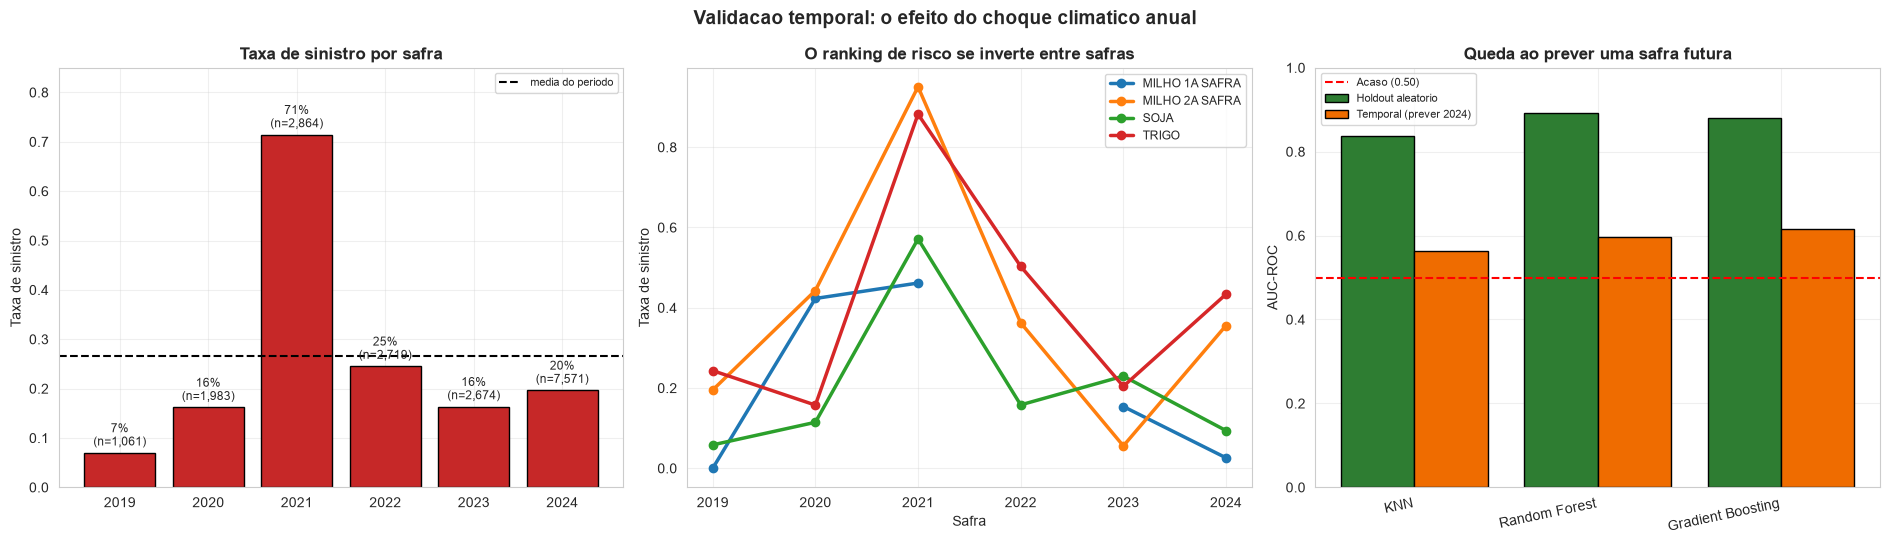

Taxa de sinistro por safra e cultura (%):
NM_CULTURA_GLOBAL  MILHO 1A SAFRA  MILHO 2A SAFRA  SOJA  TRIGO
ANO_APOLICE                                                   
2019                          0.0            19.5   5.8   24.3
2020                         42.3            44.3  11.5   15.7
2021                         46.2            95.1  57.2   88.2
2022                          NaN            36.2  15.8   50.3
2023                         15.4             5.6  23.0   20.4
2024                          2.6            35.6   9.4   43.4


In [33]:
# Por que a performance cai? O ranking de risco se INVERTE entre as safras.
top_cult = df['NM_CULTURA_GLOBAL'].value_counts().head(4).index
pivot_ano = (df[df['NM_CULTURA_GLOBAL'].isin(top_cult)]
             .pivot_table(index='ANO_APOLICE', columns='NM_CULTURA_GLOBAL',
                          values='TEVE_SINISTRO', aggfunc='mean'))

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (a) Taxa de sinistro por safra
taxa_ano = df.groupby('ANO_APOLICE')['TEVE_SINISTRO'].agg(['mean', 'size'])
axes[0].bar(taxa_ano.index.astype(str), taxa_ano['mean'], color='#C62828', edgecolor='black')
axes[0].axhline(df['TEVE_SINISTRO'].mean(), color='black', ls='--', label='media do periodo')
for i, (m, n) in enumerate(zip(taxa_ano['mean'], taxa_ano['size'])):
    axes[0].text(i, m + 0.015, f'{m*100:.0f}%\n(n={n:,})', ha='center', fontsize=8.5)
axes[0].set_title('Taxa de sinistro por safra', fontweight='bold')
axes[0].set_ylabel('Taxa de sinistro'); axes[0].set_ylim(0, 0.85); axes[0].legend(fontsize=8)

# (b) Inversao do ranking entre culturas
for c in pivot_ano.columns:
    axes[1].plot(pivot_ano.index.astype(int), pivot_ano[c], marker='o', lw=2.5, label=c)
axes[1].set_title('O ranking de risco se inverte entre safras', fontweight='bold')
axes[1].set_xlabel('Safra'); axes[1].set_ylabel('Taxa de sinistro')
axes[1].legend(fontsize=8.5)

# (c) Holdout aleatorio vs temporal
x = np.arange(len(df_temp))
axes[2].bar(x - 0.2, df_temp['auc_holdout_aleatorio'], 0.4,
            label='Holdout aleatorio', color='#2E7D32', edgecolor='black')
axes[2].bar(x + 0.2, df_temp['auc_temporal_2024'], 0.4,
            label='Temporal (prever 2024)', color='#EF6C00', edgecolor='black')
axes[2].axhline(0.5, color='red', ls='--', label='Acaso (0.50)')
axes[2].set_xticks(x); axes[2].set_xticklabels(df_temp.index, rotation=12, ha='right')
axes[2].set_ylabel('AUC-ROC'); axes[2].set_ylim(0, 1.0)
axes[2].set_title('Queda ao prever uma safra futura', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Validacao temporal: o efeito do choque climatico anual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_validacao_temporal.png', dpi=110, bbox_inches='tight')
plt.show()

print("Taxa de sinistro por safra e cultura (%):")
print((pivot_ano * 100).round(1).to_string())

In [34]:
# O sinal existe DENTRO de cada safra? Holdout 80/20 isolado por ano.
print("AUC intra-safra (holdout 80/20 dentro de cada ano, Random Forest)")
print("=" * 66)
linhas_intra = []
for ano in sorted(df['ANO_APOLICE'].dropna().unique()):
    sub = df[df['ANO_APOLICE'] == ano]
    if len(sub) < 400 or sub['TEVE_SINISTRO'].nunique() < 2:
        continue
    Xa, Xb, ya, yb = train_test_split(sub[FEATURES], sub['TEVE_SINISTRO'],
                                      test_size=TEST_SIZE, random_state=RANDOM_STATE,
                                      stratify=sub['TEVE_SINISTRO'])
    p = Pipeline([('pre', criar_preprocessador()),
                  ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                 random_state=RANDOM_STATE, n_jobs=-1))])
    p.fit(Xa, ya)
    auc_ano = roc_auc_score(yb, p.predict_proba(Xb)[:, 1])
    linhas_intra.append({'safra': int(ano), 'n': len(sub),
                         'taxa_sinistro': sub['TEVE_SINISTRO'].mean(), 'auc': auc_ano})
    print(f"  {int(ano)} | n={len(sub):5,} | taxa={sub['TEVE_SINISTRO'].mean()*100:5.1f}% "
          f"| AUC = {auc_ano:.4f}")

df_intra = pd.DataFrame(linhas_intra)
print("=" * 66)
print(f"AUC intra-safra medio: {df_intra['auc'].mean():.4f} "
      f"(min {df_intra['auc'].min():.4f} | max {df_intra['auc'].max():.4f})")

AUC intra-safra (holdout 80/20 dentro de cada ano, Random Forest)


  2019 | n=1,061 | taxa=  7.0% | AUC = 0.8111


  2020 | n=1,983 | taxa= 16.2% | AUC = 0.8454


  2021 | n=2,864 | taxa= 71.4% | AUC = 0.9315


  2022 | n=2,719 | taxa= 24.5% | AUC = 0.8837


  2023 | n=2,674 | taxa= 16.3% | AUC = 0.8343


  2024 | n=7,571 | taxa= 19.7% | AUC = 0.8457
AUC intra-safra medio: 0.8586 (min 0.8111 | max 0.9315)


### 11.2 De onde vem a diferenca entre 0,89 e 0,60?

O salto entre o holdout aleatorio e o teste out-of-time e grande demais para ficar
sem explicacao. Comecamos verificando a promessa feita na Secao 4.5 - se excluir
`ANO_APOLICE` realmente tirou o ano do modelo - e depois decompomos a diferenca em
tres parcelas, medindo cada uma:

1. **Efeito de coorte** - parte do AUC vem de ordenar safras, nao apolices.
   Medimos calculando o AUC **dentro de cada safra** e ponderando pelo tamanho:
   isso neutraliza a comparacao entre anos.
2. **Vazamento de grupo** - a base tem 18.872 apolices para cerca de 10,6 mil
   segurados. Um split aleatorio coloca o **mesmo produtor** nos dois lados.
   Medimos com `GroupShuffleSplit` agrupando por documento do segurado.
3. **Falha genuina de transferencia entre safras** - o que sobra.

In [35]:
# Teste de honestidade: remover a coluna ANO_APOLICE realmente remove o ano?
CAL = ['MES_INICIO', 'MES_FIM', 'DURACAO_VIGENCIA_DIAS', 'DIAS_PROPOSTA_APOLICE']
_ano = df['ANO_APOLICE'].astype(int)
_maj = _ano.value_counts(normalize=True).max()


def _pre_subset(cols):
    """Pre-processador restrito a um subconjunto de colunas."""
    return ColumnTransformer([
        ('num', Pipeline([('i', SimpleImputer(strategy='median')), ('s', StandardScaler())]),
         [c for c in cols if c in FEATURES_NUMERICAS]),
        ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                          ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
         [c for c in cols if c in FEATURES_CATEGORICAS])])


print("O ANO E RECUPERAVEL A PARTIR DAS FEATURES QUE MANTIVEMOS?")
print("=" * 74)
for rotulo, cols in [('todas as features do modelo', FEATURES),
                     ('features SEM o calendario', [c for c in FEATURES if c not in CAL]),
                     ('apenas as 4 de calendario', CAL)]:
    _a, _b, _ya, _yb = train_test_split(df[cols], _ano, test_size=TEST_SIZE,
                                        random_state=RANDOM_STATE, stratify=_ano)
    _p = Pipeline([('pre', _pre_subset(cols)),
                   ('clf', RandomForestClassifier(n_estimators=300,
                            random_state=RANDOM_STATE, n_jobs=-1))]).fit(_a, _ya)
    print(f"  acerta a safra exata com {rotulo:29s}: {accuracy_score(_yb, _p.predict(_b))*100:5.1f}%")
print(f"  {'chute na classe majoritaria':56s}: {_maj*100:5.1f}%")
print("=" * 74)

O ANO E RECUPERAVEL A PARTIR DAS FEATURES QUE MANTIVEMOS?


  acerta a safra exata com todas as features do modelo  :  97.1%


  acerta a safra exata com features SEM o calendario    :  95.5%


  acerta a safra exata com apenas as 4 de calendario    :  67.7%
  chute na classe majoritaria                             :  40.1%


**O teste reprova a versao ingenua do nosso proprio argumento - e registramos
isso.** Remover a coluna `ANO_APOLICE` **nao** remove o ano do modelo. O conjunto
completo de features identifica a safra exata em cerca de **97% dos casos**, contra
40% de chute. Mais revelador ainda: mesmo **descartando todas as variaveis de
calendario**, a recuperacao continua em torno de **95%** - porque os valores
monetarios, as taxas e as produtividades tambem evoluem ano a ano. O calendario
sozinho ja acerta cerca de dois tercos.

Ou seja: **nao existe subconjunto razoavel de features que apague a safra.** O ano
nao esta numa coluna, esta difundido em todas elas.

**Isso e vazamento?** Nao do target. Todas essas variaveis sao contratuais e
conhecidas na subscricao; nenhuma informacao posterior ao sinistro entra no modelo.
O que existe e um **efeito de coorte** induzido pelo desenho amostral: num split
aleatorio sobre seis safras, treino e teste compartilham os mesmos anos, e o modelo
pode se apoiar em "esta apolice parece de 2021" - safra em que 71,4% das apolices
sinistraram.

A pergunta certa deixa de ser *"conseguimos eliminar o ano?"* (nao conseguimos) e
passa a ser **"quanto do nosso AUC vem disso?"** - que e o que a decomposicao
abaixo responde.

In [36]:
_clf_final = clone(modelo_final)                 # mesmos hiperparametros, nao treinado
_prob_hold = modelo_final.predict_proba(X_test)[:, 1]
_auc_hold = roc_auc_score(y_test, _prob_hold)


def _auc_ponderado_por_safra(anos, y_true, prob):
    """AUC calculado DENTRO de cada safra e ponderado pelo n de cada uma."""
    num = den = 0.0
    for a in sorted(pd.Series(anos).unique()):
        m = (pd.Series(anos).to_numpy() == a)
        if pd.Series(y_true).to_numpy()[m].std() == 0:
            continue
        num += roc_auc_score(pd.Series(y_true).to_numpy()[m], prob[m]) * m.sum()
        den += m.sum()
    return num / den


# (1) efeito de coorte
_auc_intra = _auc_ponderado_por_safra(df.loc[X_test.index, 'ANO_APOLICE'], y_test, _prob_hold)

# (2) vazamento de grupo: nenhum segurado aparece nos dois lados
from sklearn.model_selection import GroupShuffleSplit

_grupos = df['NR_DOCUMENTO_SEGURADO'].fillna('SEM_DOC')
_itr, _ite = next(GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE,
                                    random_state=RANDOM_STATE).split(X, y, groups=_grupos))
_Xg_tr, _Xg_te = X.iloc[_itr].copy(), X.iloc[_ite].copy()
_fq = df.iloc[_itr]['NM_MUNICIPIO_PROPRIEDADE'].value_counts(normalize=True)
_Xg_tr['FREQ_MUNICIPIO'] = df.iloc[_itr]['NM_MUNICIPIO_PROPRIEDADE'].map(_fq).fillna(0.0).values
_Xg_te['FREQ_MUNICIPIO'] = df.iloc[_ite]['NM_MUNICIPIO_PROPRIEDADE'].map(_fq).fillna(0.0).values

_clf_final.fit(_Xg_tr, y.iloc[_itr])
_prob_g = _clf_final.predict_proba(_Xg_te)[:, 1]
_auc_grupo = roc_auc_score(y.iloc[_ite], _prob_g)
_auc_limpo = _auc_ponderado_por_safra(df.iloc[_ite]['ANO_APOLICE'], y.iloc[_ite], _prob_g)

_auc_oot = df_temp.loc[melhor_final, 'auc_temporal_2024']
_sobrep = df.loc[X_test.index, 'NR_DOCUMENTO_SEGURADO'].isin(
    df.loc[X_train.index, 'NR_DOCUMENTO_SEGURADO']).mean()

print(f"Segurados distintos: {_grupos.nunique():,} para {len(df):,} apolices "
      f"({len(df)/_grupos.nunique():.2f} apolices por segurado)")
print(f"Linhas do holdout cujo segurado tambem esta no treino: {_sobrep*100:.1f}%\n")

_decomp = pd.DataFrame([
    ['(a) Holdout aleatorio (numero reportado)', _auc_hold, np.nan],
    ['(b) ... medindo so DENTRO de cada safra',  _auc_intra, _auc_intra - _auc_hold],
    ['(c) ... com split por SEGURADO',           _auc_grupo, _auc_grupo - _auc_hold],
    ['(d) ... por segurado E dentro da safra',   _auc_limpo, _auc_limpo - _auc_hold],
    ['(e) Out-of-time: treino <=2023, teste 2024', _auc_oot, _auc_oot - _auc_hold],
], columns=['cenario', 'AUC', 'delta_vs_(a)']).set_index('cenario')
print("DECOMPOSICAO DO AUC")
print("=" * 78)
print(_decomp.round(4).to_string())
print("=" * 78)

_gap = _auc_hold - _auc_oot
_artefato = _auc_hold - _auc_limpo
print(f"\nQueda total ate o out-of-time      : {_gap:.4f}")
print(f"  atribuivel a desenho amostral    : {_artefato:.4f} ({_artefato/_gap*100:.1f}%)")
print(f"  falha real de transferencia      : {_auc_limpo-_auc_oot:.4f} "
      f"({(_auc_limpo-_auc_oot)/_gap*100:.1f}%)")
print("\nEfeitos MARGINAIS (cada um medido isoladamente). Eles NAO somam ao total")
print("acima: sobrepoem-se parcialmente, e a interacao ja esta no valor agregado.")
print(f"  - efeito de coorte (safra)       : {_auc_hold-_auc_intra:.4f}")
print(f"  - vazamento de grupo (segurado)  : {_auc_hold-_auc_grupo:.4f}")

Segurados distintos: 10,602 para 18,872 apolices (1.78 apolices por segurado)
Linhas do holdout cujo segurado tambem esta no treino: 59.7%

DECOMPOSICAO DO AUC
                                               AUC  delta_vs_(a)
cenario                                                         
(a) Holdout aleatorio (numero reportado)    0.8922           NaN
(b) ... medindo so DENTRO de cada safra     0.8537       -0.0385
(c) ... com split por SEGURADO              0.8821       -0.0101
(d) ... por segurado E dentro da safra      0.8436       -0.0486
(e) Out-of-time: treino <=2023, teste 2024  0.5966       -0.2956

Queda total ate o out-of-time      : 0.2956
  atribuivel a desenho amostral    : 0.0486 (16.4%)
  falha real de transferencia      : 0.2470 (83.6%)

Efeitos MARGINAIS (cada um medido isoladamente). Eles NAO somam ao total
acima: sobrepoem-se parcialmente, e a interacao ja esta no valor agregado.
  - efeito de coorte (safra)       : 0.0385
  - vazamento de grupo (segurado)  : 0.0101

### 11.3 O achado

Os numeros acima contam uma historia consistente:

- **Dentro de cada safra** o modelo discrimina risco muito bem: AUC alto e estavel
  nas seis safras, inclusive nas de baixa sinistralidade.
- **Entre safras** a performance cai drasticamente, retendo apenas sinal residual.

A causa esta no grafico do meio: o **ranking de risco se inverte**. Milho 2a safra
foi a cultura mais sinistrada em 2021 (95,1%, na seca historica) e uma das menos
sinistradas em 2023 (5,6%). Um modelo treinado ate 2023 aprende uma ordenacao que
**deixa de valer** na safra seguinte.

**A decomposicao da Secao 11.2 mostra que a queda nao e artefato.** Uma parte
menor vem do desenho amostral - efeito de coorte e o mesmo produtor nos dois lados
do split. Mas a maior parte da diferenca **sobrevive** a correcao dos dois: mesmo
comparando so dentro da safra e sem compartilhar segurados, o AUC continua muito
acima do out-of-time. A falha de transferencia entre safras e **real**, e nao um
efeito de amostragem.

**Um detalhe que merece registro: a ordem dos modelos nao e estavel entre
protocolos.** A celula acima compara os dois rankings. O Random Forest lidera com
folga no holdout aleatorio, mas fora da amostra os dois ensembles praticamente
empatam, com vantagem para o Gradient Boosting - que tambem sofre a menor queda.

Nao trocamos o campeao: a escolha segue o protocolo definido **antes** de olhar
qualquer resultado (melhor AUC na validacao cruzada do treino). Mas registramos a
fragilidade: a diferenca entre os dois ensembles fora da amostra e pequena e se
mostrou sensivel a mudancas minimas no pre-processamento durante o desenvolvimento -
ou seja, **nao ha evidencia suficiente para eleger um vencedor out-of-time** com
uma unica safra de teste. Quem levar o modelo a producao deve reavaliar sob
protocolo temporal, idealmente com validacao em varias safras (leave-one-year-out),
e nao assumir que o campeao do holdout aleatorio se mantem.

**Conclusao tecnica.** Os atributos da apolice (cultura, area, valores, geografia)
explicam bem o risco **relativo** dentro de um mesmo contexto climatico, mas nao
capturam o **choque climatico anual**, que e o fator dominante do seguro agricola.
Para previsao out-of-time seria indispensavel incorporar variaveis climaticas com
valores efetivos (precipitacao acumulada, dias de deficit hidrico, ocorrencia de
geada) - exatamente o dado que a Sprint 2 registrou como indisponivel (estacoes
INMET com metadados, porem series mensais nulas).

Esse resultado transforma uma limitacao herdada em **requisito tecnico justificado
por evidencia** para a proxima sprint.

## 12. Comparacao com a Sprint 2 (target derivado vs target real)

Reproduzimos aqui o baseline da Sprint 2 sobre a base PSR 2025 para deixar
explicito **por que a mudanca de target foi necessaria**.

In [37]:
# --- Reproducao do target derivado da Sprint 2 sobre a base PSR 2025 ---
d2 = df_2025.copy()
for c in ['NM_CULTURA_GLOBAL', 'SG_UF_PROPRIEDADE', 'NM_CLASSIF_PRODUTO']:
    d2[c] = d2[c].apply(normalize_str)

PESOS_CULTURA = {'CEBOLA': .85, 'TOMATE': .80, 'MACA': .75, 'BATATA': .70,
                 'SORGO': .65, 'TRIGO': .55, 'MILHO 2A SAFRA': .50}
PESOS_ESTADO = {'SC': .75, 'PR': .70, 'RS': .60, 'MS': .55,
                'SP': .50, 'GO': .55, 'MG': .50, 'MT': .55}
PESOS_CLASSE = {'RECEITA': .80, 'CUSTEIO': .60, 'PRODUTIVIDADE': .50}

d2['SCORE_RISCO'] = (d2['NM_CULTURA_GLOBAL'].map(PESOS_CULTURA) * .40 +
                     d2['SG_UF_PROPRIEDADE'].map(PESOS_ESTADO) * .30 +
                     d2['NM_CLASSIF_PRODUTO'].map(PESOS_CLASSE) * .30)
d2['ALTO_RISCO'] = (d2['SCORE_RISCO'] > d2['SCORE_RISCO'].median()).astype(int)

print("Sprint 2 - o target derivado e funcao deterministica da cultura:")
print(d2.groupby('NM_CULTURA_GLOBAL')['ALTO_RISCO'].mean().round(3).to_string())
print("\nQuase todas as culturas caem em 0.0 ou 1.0: conhecer a cultura equivale")
print("a conhecer o target. O modelo nao aprendia risco - reaprendia nossa regra.")

Sprint 2 - o target derivado e funcao deterministica da cultura:
NM_CULTURA_GLOBAL
BATATA            1.000
CEBOLA            1.000
MACA              1.000
MILHO 2A SAFRA    0.002
SORGO             1.000
TOMATE            1.000
TRIGO             0.873

Quase todas as culturas caem em 0.0 ou 1.0: conhecer a cultura equivale
a conhecer o target. O modelo nao aprendia risco - reaprendia nossa regra.


In [38]:
feat_s2 = ['PE_TAXA', 'VL_SUBVENCAO_FEDERAL']
d2['PE_TAXA_EFETIVA'] = d2['VL_PREMIO_LIQUIDO'] / d2['VL_LIMITE_GARANTIA']
d2['PE_SUBVENCAO'] = d2['VL_SUBVENCAO_FEDERAL'] / d2['VL_PREMIO_LIQUIDO']
feat_s2 += ['PE_TAXA_EFETIVA', 'PE_SUBVENCAO']

X2 = d2[feat_s2].fillna(d2[feat_s2].median())
y2 = d2['ALTO_RISCO']
X2tr, X2te, y2tr, y2te = train_test_split(X2, y2, test_size=TEST_SIZE,
                                          random_state=RANDOM_STATE, stratify=y2)
rf2 = Pipeline([('sc', StandardScaler()),
                ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1))])
rf2.fit(X2tr, y2tr)
auc_s2 = roc_auc_score(y2te, rf2.predict_proba(X2te)[:, 1])

comparativo = pd.DataFrame([
    {'aspecto': 'Base de dados',            'Sprint 2': 'PSR 2025',              'Sprint 3': 'PSR 2016-2024'},
    {'aspecto': 'Apolices',                 'Sprint 2': f'{len(df_2025):,}',     'Sprint 3': f'{len(df):,}'},
    {'aspecto': 'Safras cobertas',          'Sprint 2': '1 (2025)',              'Sprint 3': '6 (2019-2024)'},
    {'aspecto': 'Natureza do target',       'Sprint 2': 'Derivado (regra nossa)','Sprint 3': 'Real (observado)'},
    {'aspecto': 'Sinistros observados',     'Sprint 2': '0',                     'Sprint 3': f'{n_sin:,}'},
    {'aspecto': 'Culturas',                 'Sprint 2': '7 (sem Soja)',          'Sprint 3': '11 (com Soja)'},
    {'aspecto': 'Features usadas',          'Sprint 2': '4 numericas',           'Sprint 3': f'{len(FEATURES)} (num + cat)'},
    {'aspecto': 'AUC do melhor modelo',     'Sprint 2': f'{auc_s2:.4f}',         'Sprint 3': f"{df_tuning.loc[melhor_final,'auc_depois']:.4f}"},
    {'aspecto': 'Tarefa de regressao',      'Sprint 2': 'Nao aplicavel',         'Sprint 3': f"R2 = {df_reg.loc[melhor_reg,'R2']:.3f}"},
    {'aspecto': 'Circularidade do target',  'Sprint 2': 'SIM (limitacao)',       'Sprint 3': 'NAO'},
])
print("=" * 96)
print("SPRINT 2 vs SPRINT 3")
print("=" * 96)
print(comparativo.to_string(index=False))
print("=" * 96)
print(f"""
O AUC da Sprint 2 ({auc_s2:.3f}) e MAIOR que o desta sprint
({df_tuning.loc[melhor_final,'auc_depois']:.3f}) - e isso e esperado e desejavel.
Prever uma regra deterministica que nos mesmos escrevemos e facil; prever um
sinistro climatico real e dificil. O numero menor desta sprint mede um problema
de verdade, e por isso vale mais.""")

SPRINT 2 vs SPRINT 3
                aspecto               Sprint 2         Sprint 3
          Base de dados               PSR 2025    PSR 2016-2024
               Apolices                  1,414           18,872
        Safras cobertas               1 (2025)    6 (2019-2024)
     Natureza do target Derivado (regra nossa) Real (observado)
   Sinistros observados                      0            5,033
               Culturas           7 (sem Soja)    11 (com Soja)
        Features usadas            4 numericas   26 (num + cat)
   AUC do melhor modelo                 0.9775           0.8922
    Tarefa de regressao          Nao aplicavel       R2 = 0.372
Circularidade do target        SIM (limitacao)              NAO

O AUC da Sprint 2 (0.978) e MAIOR que o desta sprint
(0.892) - e isso e esperado e desejavel.
Prever uma regra deterministica que nos mesmos escrevemos e facil; prever um
sinistro climatico real e dificil. O numero menor desta sprint mede um problema
de verdade, e por isso 

## 13. Persistencia dos Modelos

Serializamos os pipelines completos (pre-processamento + modelo) para uso na API
da proxima sprint. Como o `Pipeline` carrega o `StandardScaler` e o `OneHotEncoder`
ja ajustados, o scaling e o encoding sao reaplicados em producao exatamente como no
treino.

**Com uma excecao, que gravamos junto:** o `FREQ_MUNICIPIO` e construido fora do
`ColumnTransformer` (Secao 5.3) e portanto **nao** viaja dentro do `.pkl`. Sem o
mapa de frequencias do treino, quem consumir o modelo nao conseguiria montar essa
coluna a partir do dado bruto. Por isso serializamos o mapa em
`models/freq_municipio.pkl`, junto com a instrucao de uso: mapear
`NM_MUNICIPIO_PROPRIEDADE` normalizado e preencher com 0 os municipios ausentes.

In [39]:
os.makedirs('models', exist_ok=True)

# compress=3 reduz os arquivos em cerca de 5x sem qualquer perda de precisao:
# ensembles de arvores sao muito redundantes e comprimem bem.
joblib.dump(modelo_final, 'models/classificador_sinistro.pkl', compress=3)
joblib.dump(pipelines_reg[melhor_reg], 'models/regressor_severidade.pkl', compress=3)

# O mapa de frequencias por municipio, sem o qual os .pkl nao sao aplicaveis a dado
# bruto. E o MESMO mapa usado pelos dois modelos (ajustado so no treino, Secao 5.3).
joblib.dump(_freq_treino, 'models/freq_municipio.pkl')

metadados = {
    'projeto': 'SOMPO 2026 - Sprint 3 - Modelagem de ML',
    'base': 'PSR 2016-2024 (SISSER/MAPA) - recorte Sompo Seguros S/A',
    'periodo': '2019-2024',
    'n_apolices': int(len(df)),
    'classificacao': {
        'modelo': melhor_final,
        'target': 'TEVE_SINISTRO',
        'hiperparametros': {k: str(v) for k, v in buscas[melhor_final].best_params_.items()},
        'auc_roc': float(df_tuning.loc[melhor_final, 'auc_depois']),
        'f1': float(df_tuning.loc[melhor_final, 'f1_depois']),
        'accuracy': float(df_tuning.loc[melhor_final, 'accuracy']),
        'precision': float(df_tuning.loc[melhor_final, 'precision']),
        'recall': float(df_tuning.loc[melhor_final, 'recall']),
    },
    'regressao': {
        'modelo': melhor_reg,
        'target': 'VL_INDENIZACAO',
        'mae': float(df_reg.loc[melhor_reg, 'MAE']),
        'rmse': float(df_reg.loc[melhor_reg, 'RMSE']),
        'r2': float(df_reg.loc[melhor_reg, 'R2']),
    },
    'features_numericas': FEATURES_NUMERICAS,
    'features_categoricas': FEATURES_CATEGORICAS,
    'random_state': RANDOM_STATE,
    'sklearn_version': sklearn.__version__,
    'freq_municipio': {
        'arquivo': 'models/freq_municipio.pkl',
        'como_usar': ("mapear NM_MUNICIPIO_PROPRIEDADE normalizado (sem acento, "
                      "maiuscula) contra este Series e preencher ausentes com 0.0"),
        'n_municipios': int(_freq_treino.shape[0]),
        'ajustado_em': 'apenas o conjunto de treino do holdout 80/20',
    },
}
with open('models/metadata.json', 'w', encoding='utf-8') as fp:
    json.dump(metadados, fp, indent=2, ensure_ascii=False)

# Tabela consolidada de resultados, para auditoria externa
df_tuning.to_csv('models/resultados_classificacao.csv')
df_reg.to_csv('models/resultados_regressao.csv')
df_temp.to_csv('models/resultados_validacao_temporal.csv')

print("Artefatos gravados em models/:")
for f in sorted(os.listdir('models')):
    print(f"  {f:38s} {os.path.getsize(os.path.join('models', f))/1024:8.1f} KB")

Artefatos gravados em models/:
  classificador_sinistro.pkl              19893.6 KB
  freq_municipio.pkl                         41.9 KB
  metadata.json                               1.8 KB
  regressor_severidade.pkl                24595.5 KB
  resultados_classificacao.csv                0.6 KB
  resultados_regressao.csv                    0.6 KB
  resultados_validacao_temporal.csv           0.3 KB


In [40]:
# Verificacao: recarregar do disco e confirmar que a predicao e identica
modelo_recarregado = joblib.load('models/classificador_sinistro.pkl')
prob_orig = modelo_final.predict_proba(X_test)[:, 1]
prob_novo = modelo_recarregado.predict_proba(X_test)[:, 1]

print(f"[VERIFICACAO] diferenca maxima entre o modelo em memoria e o recarregado: "
      f"{np.abs(prob_orig - prob_novo).max():.2e}")
assert np.allclose(prob_orig, prob_novo), "O modelo serializado nao reproduz as predicoes"
print("[VERIFICACAO] OK - o modelo persistido reproduz exatamente as predicoes.")

# Exemplo de uso: escoragem de 5 apolices do holdout
exemplo = X_test.head(5).copy()
exemplo_out = pd.DataFrame({
    'cultura': exemplo['NM_CULTURA_GLOBAL'].values,
    'UF': exemplo['SG_UF_PROPRIEDADE'].values,
    'area_ha': exemplo['NR_AREA_TOTAL'].round(1).values,
    'limite_R$': exemplo['VL_LIMITE_GARANTIA'].round(0).values,
    'prob_sinistro': modelo_recarregado.predict_proba(exemplo)[:, 1].round(4),
    'sinistro_real': y_test.head(5).values,
})
print("\nExemplo de escoragem (5 apolices do holdout):")
print(exemplo_out.to_string(index=False))

[VERIFICACAO] diferenca maxima entre o modelo em memoria e o recarregado: 2.22e-16
[VERIFICACAO] OK - o modelo persistido reproduz exatamente as predicoes.

Exemplo de escoragem (5 apolices do holdout):
       cultura UF  area_ha  limite_R$  prob_sinistro  sinistro_real
          SOJA SP     69.9   391386.0         0.2602              1
          SOJA MS     92.9   465156.0         0.4705              0
          SOJA SP      7.3    22869.0         0.0163              0
MILHO 2A SAFRA PR    227.5   658955.0         0.1721              0
          SOJA MT    390.0  1345500.0         0.1950              0


## 14. Conclusoes

### 14.1 Cumprimento dos requisitos do desafio

In [41]:
checklist = pd.DataFrame([
    ['1. Preparacao - scaling',        'StandardScaler dentro do Pipeline (essencial para o KNN)', 'Secao 5.2'],
    ['1. Preparacao - encoding',       f'OneHotEncoder em {len(FEATURES_CATEGORICAS)} categoricas + frequency encoding do municipio', 'Secoes 4.4 e 5.2'],
    ['2. Treinamento - >= 2 modelos',  'KNN, Random Forest e Gradient Boosting (+ baseline Dummy)', 'Secao 6'],
    ['3. Validacao - holdout',         f'Holdout estratificado 80/20 ({len(X_test):,} apolices reservadas)', 'Secao 5.3'],
    ['3. Metricas - classificacao',    'accuracy, precision, recall, f1-score, AUC-ROC (+ AP e CV k=5)', 'Secao 7'],
    ['3. Metricas - regressao',        'MAE, RMSE, R2 na severidade em R$', 'Secao 9'],
    ['4. Tuning de hiperparametros',   f'GridSearchCV; k do KNN otimizado ({gs_knn.best_params_["clf__n_neighbors"]}) + RF e GB', 'Secao 8'],
    ['5. Interpretacao',               'Feature importance + permutation importance + leitura de negocio', 'Secao 10'],
    ['Extra - validacao temporal',     'Teste out-of-time treinando ate 2023 e prevendo 2024', 'Secao 11'],
    ['Extra - comparativo Sprint 2',   'Target derivado vs target real, lado a lado', 'Secao 12'],
    ['Extra - persistencia',           'Pipelines .pkl + metadata.json + CSVs de resultados', 'Secao 13'],
], columns=['Requisito', 'Como foi atendido', 'Onde'])

print("=" * 122)
print("CHECKLIST DO 3o ENTREGAVEL")
print("=" * 122)
print(checklist.to_string(index=False))
print("=" * 122)

CHECKLIST DO 3o ENTREGAVEL
                    Requisito                                                Como foi atendido             Onde
      1. Preparacao - scaling         StandardScaler dentro do Pipeline (essencial para o KNN)        Secao 5.2
     1. Preparacao - encoding OneHotEncoder em 3 categoricas + frequency encoding do municipio Secoes 4.4 e 5.2
2. Treinamento - >= 2 modelos        KNN, Random Forest e Gradient Boosting (+ baseline Dummy)          Secao 6
       3. Validacao - holdout          Holdout estratificado 80/20 (3,775 apolices reservadas)        Secao 5.3
  3. Metricas - classificacao   accuracy, precision, recall, f1-score, AUC-ROC (+ AP e CV k=5)          Secao 7
      3. Metricas - regressao                                MAE, RMSE, R2 na severidade em R$          Secao 9
 4. Tuning de hiperparametros                  GridSearchCV; k do KNN otimizado (21) + RF e GB          Secao 8
             5. Interpretacao Feature importance + permutation importance + l

In [42]:
print("=" * 78)
print("RESUMO EXECUTIVO DOS RESULTADOS")
print("=" * 78)
print(f"""
BASE
  PSR 2016-2024 (SISSER/MAPA), recorte Sompo Seguros S/A
  {len(df):,} apolices | 2019-2024 | {n_sin:,} sinistros reais ({df['TEVE_SINISTRO'].mean()*100:.1f}%)
  {len(FEATURES)} features ({len(FEATURES_NUMERICAS)} numericas + {len(FEATURES_CATEGORICAS)} categoricas
  -> {len(nomes_features)} colunas apos scaling e OHE)

TAREFA A - CLASSIFICACAO (havera sinistro?)
  Modelo campeao : {melhor_final}
  AUC-ROC        : {df_tuning.loc[melhor_final,'auc_depois']:.4f}   (acaso = 0.5000)
  Accuracy       : {df_tuning.loc[melhor_final,'accuracy']:.4f}
  Precision      : {df_tuning.loc[melhor_final,'precision']:.4f}
  Recall         : {df_tuning.loc[melhor_final,'recall']:.4f}
  F1-score       : {df_tuning.loc[melhor_final,'f1_depois']:.4f}

TAREFA B - REGRESSAO (quanto custa o sinistro?)
  Modelo campeao : {melhor_reg}
  MAE            : R$ {df_reg.loc[melhor_reg,'MAE']:,.0f}
  RMSE           : R$ {df_reg.loc[melhor_reg,'RMSE']:,.0f}
  R2             : {df_reg.loc[melhor_reg,'R2']:.4f}

TUNING
  k otimo do KNN : {gs_knn.best_params_['clf__n_neighbors']} vizinhos ({gs_knn.best_params_['clf__metric']}, {gs_knn.best_params_['clf__weights']})
  Ganho de AUC no KNN com o tuning: {df_tuning.loc['KNN','ganho_auc']:+.4f}

ROBUSTEZ
  AUC intra-safra medio        : {df_intra['auc'].mean():.4f}
  AUC do campeao prevendo 2024 : {df_temp.loc[melhor_final, 'auc_temporal_2024']:.4f}
""")
print("=" * 78)

RESUMO EXECUTIVO DOS RESULTADOS

BASE
  PSR 2016-2024 (SISSER/MAPA), recorte Sompo Seguros S/A
  18,872 apolices | 2019-2024 | 5,033 sinistros reais (26.7%)
  26 features (23 numericas + 3 categoricas
  -> 47 colunas apos scaling e OHE)

TAREFA A - CLASSIFICACAO (havera sinistro?)
  Modelo campeao : Random Forest
  AUC-ROC        : 0.8922   (acaso = 0.5000)
  Accuracy       : 0.8474
  Precision      : 0.7149
  Recall         : 0.7120
  F1-score       : 0.7134

TAREFA B - REGRESSAO (quanto custa o sinistro?)
  Modelo campeao : Random Forest
  MAE            : R$ 43,802
  RMSE           : R$ 91,291
  R2             : 0.3722

TUNING
  k otimo do KNN : 21 vizinhos (manhattan, distance)
  Ganho de AUC no KNN com o tuning: +0.0343

ROBUSTEZ
  AUC intra-safra medio        : 0.8586
  AUC do campeao prevendo 2024 : 0.5966



### 14.2 Quais variaveis mais impactam o risco (resposta ao item 5)

A resposta abaixo sai da convergencia entre as tres leituras da Secao 10
(importancia de impureza, permutation importance individual e por bloco) e a
evidencia descritiva.

**1. A janela de exposicao climatica e o fator dominante.**
Na permutation importance individual, `DURACAO_VIGENCIA_DIAS` e a variavel cujo
embaralhamento mais derruba o AUC. Junto com `MES_INICIO` e `MES_FIM`, ela forma o
bloco mais importante do modelo por larga margem.

**Cuidado com a leitura causal.** Seria tentador concluir "mais dias de vigencia =
mais tempo exposto = mais risco". **Os dados nao sustentam isso.** A correlacao
marginal entre duracao e sinistro e praticamente nula e de sinal *negativo*
(-0,045), e a relacao nao e monotonica: as apolices mais curtas (ate 150 dias) tem
32,7% de sinistralidade, as intermediarias caem para cerca de 17%, e as mais longas
voltam a 30,4%. A prova definitiva vem da comparacao direta: **Soja e Milho 2a safra
tem exatamente a mesma duracao mediana (150 dias) e taxas de sinistro de 18,9% e
42,2%**.

A duracao nao mede dose de exposicao - ela funciona como **impressao digital do
calendario da cultura**. Combinada com o mes de inicio e de fim, identifica em que
janela do ano a lavoura esta no campo, e e a janela (inverno seco x verao chuvoso)
que carrega o risco. Isso explica por que o item 2 abaixo e a leitura correta.

**2. A cultura age atraves do calendario, nao ao lado dele.**
Tomada isoladamente, `NM_CULTURA_GLOBAL` tem permutation importance quase nula -
mas isso **nao** significa que a cultura seja irrelevante. A cultura *determina* a
janela de plantio, entao sua informacao ja esta embutida nas variaveis de
calendario. Por isso a analise por bloco (Secao 10.3) e a leitura correta: o bloco
*"Cultura e calendario agricola"* e o mais importante do modelo. Descritivamente,
Milho 2a safra e Sorgo - plantados na janela seca do inverno - sinistram cerca de
duas vezes mais que a Soja, plantada no periodo chuvoso.

**3. Geografia e o segundo bloco mais forte.**
`LON_DECIMAL` lidera a importancia de impureza nos dois modelos de arvore e fica em
segundo na permutation importance individual - as duas leituras concordam, e ambas
a colocam acima de `LAT_DECIMAL` e da propria UF. A longitude separa a fronteira
agricola do Centro-Oeste (MT com 49,6% e MS com 41,8% de sinistralidade) das
lavouras do Sul. As coordenadas discriminam melhor que a UF porque capturam
microrregiao, e nao apenas a divisa administrativa.

**4. Precificacao e cobertura entram com peso moderado.**
`VL_LIMITE_POR_HA`, `PE_TAXA`, `PE_TAXA_EFETIVA` e `PE_SUBVENCAO` aparecem no meio
do ranking. A taxa cobrada correlaciona-se **positivamente, porem fracamente**, com
o sinistro observado: o decil de menor taxa registra cerca de 21% de sinistralidade
contra cerca de 30% no decil de maior taxa. A subscricao atual aponta na direcao
certa, mas com poder de separacao modesto - exatamente a lacuna que um modelo
preditivo se propoe a cobrir.

**5. Escala e valor absoluto praticamente nao discriminam.**
`NR_AREA_TOTAL` e `VL_LIMITE_GARANTIA` ficam proximos de zero. Faz sentido: o
sinistro climatico atinge a lavoura independentemente do tamanho dela. O que pesa e
o valor segurado *por hectare* (intensidade da cobertura), nao o valor total.

**6. O complementar da CONAB agrega pouco, e sabemos por que.**
`CONAB_AREA_CANA_UF` e `SG_UF_PROPRIEDADE` marcam praticamente a mesma importancia
individual, ambas baixas. Nao e coincidencia: a area de cana e **constante dentro de
cada UF**, logo as duas carregam a mesma informacao e embaralhar uma nao machuca
enquanto a outra permanece. O sinal geografico util esta nas **coordenadas**, que
discriminam microrregiao, e nao no agregado estadual.

Vale o registro de processo: esta sprint descobriu que o join com a CONAB herdado da
Sprint 2 estava quebrado (cabecalho lido na linha errada e mapeamento de UF por
nome, quando a planilha usa siglas) e a coluna vinha 100% nula. Corrigido o join, a
variavel passou a ter valores reais - e a conclusao acima e sobre a variavel
funcionando, nao sobre um bug. Nem todo enriquecimento de base se converte em poder
preditivo, mas essa afirmacao so vale depois de garantir que o dado chegou.

### 14.3 Limitacoes

1. **Ausencia de variaveis climaticas efetivas.** E a limitacao dominante,
   demonstrada empiricamente na Secao 11. As series mensais do INMET
   disponiveis estao nulas; usamos apenas metadados geograficos das estacoes.
2. **Generalizacao temporal limitada.** O modelo ordena risco muito bem dentro
   de uma safra, mas nao antecipa o choque climatico da safra seguinte.
3. **O AUC do holdout aleatorio nao e o AUC de producao.** A Secao 11.2 decompoe
   a diferenca: parte vem de **efeito de coorte** (o ano permanece recuperavel a
   ~97% mesmo sem a coluna `ANO_APOLICE`) e parte de **vazamento de grupo** (a base
   tem ~1,78 apolice por segurado, e o split aleatorio poe o mesmo produtor nos dois
   lados). O numero corrigido para os dois efeitos e menor que o reportado, e o
   out-of-time e menor ainda. Reportamos o holdout aleatorio porque e o que o
   enunciado exige, sempre acompanhado dessa decomposicao.
4. **Severidade parcialmente explicada.** Alem da falta de dados de intensidade do
   evento, **18% das apolices sinistradas tem indenizacao de R$ 0** (evento
   registrado sem pagamento apurado) e foram mantidas no alvo. O modelo precisa
   aprender simultaneamente *se* havera pagamento e *de quanto* ele sera, o que
   limita o R2. O valor pontual do holdout tambem e instavel: o desvio da validacao
   cruzada e a medida honesta dessa incerteza.
5. **Qualidade do dado de origem.** A base do MAPA traz erros de digitacao - por
   exemplo, uma apolice com `DT_FIM_VIGENCIA` em 5207, saneada na Secao 4.4. Nao
   fizemos auditoria exaustiva de todos os campos.
6. **Complementares com contribuicao desigual.** Os joins com IBGE e CONAB tiveram
   de ser refeitos nesta sprint (a chave herdada da Sprint 2 estava incorreta em
   ambos). Mesmo corrigidos, sua contribuicao preditiva e pequena: `CONAB_AREA_CANA_UF`
   e constante dentro da UF, e o IBGE serve como validacao cadastral, nao como
   feature. O unico complementar com efeito direto no modelo e a distancia a estacao
   INMET mais proxima.
7. **Escopo da carteira.** O recorte cobre 10 UFs e 11 culturas, com forte
   concentracao em Soja e Milho 2a safra no Sul e Sudeste. Culturas e regioes
   pouco representadas tem estimativas menos confiaveis.
8. **Vies de selecao do PSR.** A base cobre apenas apolices com subvencao
   federal; contratos privados sem subvencao nao aparecem.
9. **Dominio.** O desafio menciona maquinas agricolas, enquanto o PSR cobre
   culturas. O dominio de risco climatico rural e analogo, porem nao identico -
   limitacao ja declarada na Sprint 2 e mantida aqui por transparencia.

### 14.4 Proximos passos (Sprint 4)

1. **Integrar dados climaticos com valores efetivos** - NASA POWER ou series
   historicas completas do INMET, agregando precipitacao acumulada, deficit
   hidrico e dias de geada na janela de vigencia de cada apolice. A Secao 11
   fornece a justificativa empirica para priorizar esse item.
2. **Revalidar o ganho out-of-time** - repetir o teste temporal apos incluir
   o clima e medir a recuperacao do AUC na previsao da safra seguinte.
3. **Modelo de premio puro** - combinar as duas tarefas
   (`probabilidade x severidade`) num unico indicador monetario de risco
   por apolice.
4. **Explicabilidade individual** - SHAP values para justificar cada score no
   dashboard, atendendo ao requisito de relatorios explicaveis do desafio.
5. **Servir o modelo** - expor `models/classificador_sinistro.pkl` e
   `models/regressor_severidade.pkl` na API e alimentar os dashboards e
   rankings de risco previstos no projeto.

---

## Referencias

- **MAPA - Dados Abertos, SISSER** (base principal):
  https://dados.agricultura.gov.br/dataset/sisser3
  Recurso *"PSR - 2016 a 2024"*, 1.048.565 apolices de todo o mercado segurador.
- **MAPA - Atlas do Seguro Rural**:
  https://www.gov.br/agricultura/pt-br/assuntos/riscos-seguro
- **CONAB - Serie Historica de Safras**: https://www.conab.gov.br/
- **IBGE - Codigos de Municipios**: https://www.ibge.gov.br/
- **INMET - Banco de Dados Meteorologicos**: https://bdmep.inmet.gov.br/
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12.
- Chapman et al. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*.

---

**Repositorio:** https://github.com/orugian/sprint3-ml
**Reproducao:** `pip install -r requirements.txt` e executar este notebook do
inicio ao fim. O script `scripts/prepare_data.py` documenta a obtencao da base
bruta a partir da fonte oficial do MAPA.